<a href="https://colab.research.google.com/github/jabjabhaider-ui/database-files1/blob/main/Copy_of_Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#1.Canada

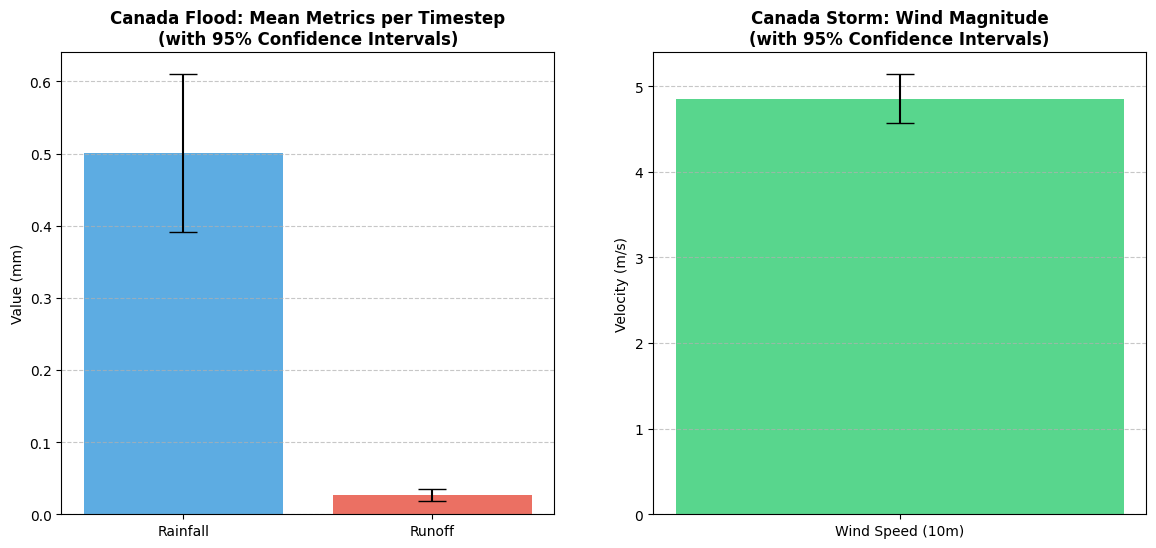

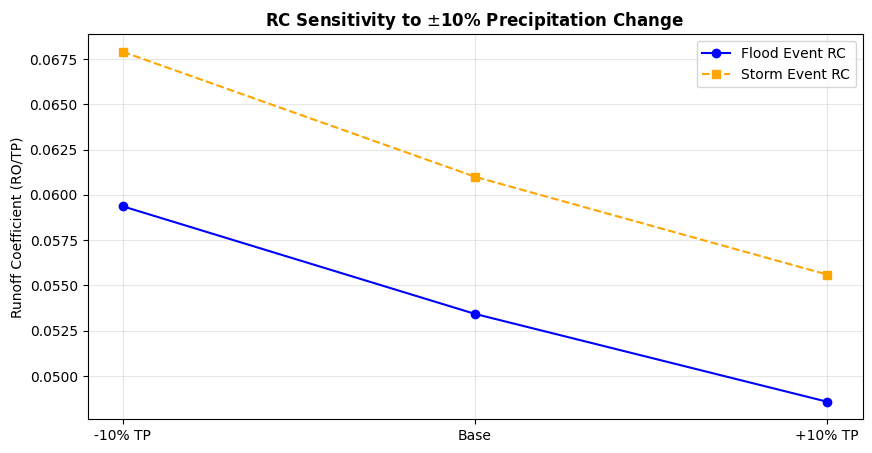

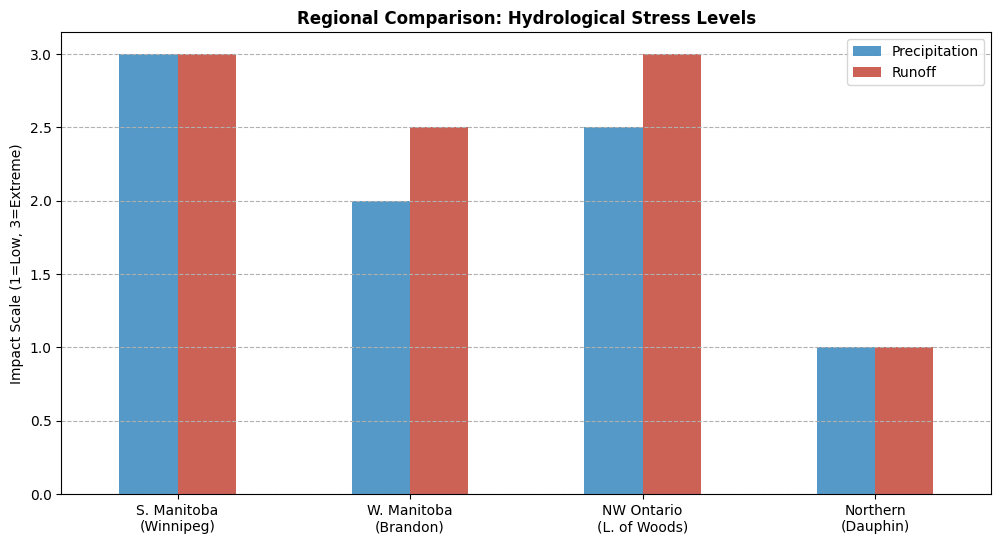

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 10, 'figure.figsize': (12, 10)})

# Data Preparation
flood_metrics = {
    'Variable': ['Rainfall (mm)', 'Runoff (mm)'],
    'Mean': [0.5005, 0.02674],
    'CI_Low': [0.391, 0.0188],
    'CI_High': [0.610, 0.0347]
}

storm_metrics = {
    'Variable': ['Rainfall (mm)', 'Runoff (mm)', 'Wind Speed (m/s)'],
    'Mean': [0.368, 0.0225, 4.85],
    'CI_Low': [0.298, 0.0195, 4.57],
    'CI_High': [0.439, 0.0255, 5.14]
}

sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.05937, 0.05343, 0.04858],
    'Storm_RC': [0.0679, 0.061, 0.0556]
}

# --- Plot 1: Summary ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
variables = ['Rainfall', 'Runoff']
means = [flood_metrics['Mean'][0], flood_metrics['Mean'][1]]
yerr = [[means[0]-flood_metrics['CI_Low'][0], means[1]-flood_metrics['CI_Low'][1]],
        [flood_metrics['CI_High'][0]-means[0], flood_metrics['CI_High'][1]-means[1]]]

ax1.bar(variables, means, yerr=yerr, capsize=10, color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_title('Canada Flood: Mean Metrics per Timestep\n(with 95% Confidence Intervals)', fontweight='bold')
ax1.set_ylabel('Value (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

wind_mean = storm_metrics['Mean'][2]
wind_err = [[wind_mean - storm_metrics['CI_Low'][2]], [storm_metrics['CI_High'][2] - wind_mean]]
ax2.bar(['Wind Speed (10m)'], [wind_mean], yerr=wind_err, capsize=10, color='#2ecc71', alpha=0.8)
ax2.set_title('Canada Storm: Wind Magnitude\n(with 95% Confidence Intervals)', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Sensitivity ---
plt.figure(figsize=(10, 5))
plt.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Flood Event RC', color='blue')
plt.plot(sensitivity_data['Scenario'], sensitivity_data['Storm_RC'], marker='s', label='Storm Event RC', color='orange', linestyle='--')
plt.title(r'RC Sensitivity to $\pm$10% Precipitation Change', fontweight='bold')
plt.ylabel('Runoff Coefficient (RO/TP)')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot 3: Regional Impact ---
regions = ['S. Manitoba\n(Winnipeg)', 'W. Manitoba\n(Brandon)', 'NW Ontario\n(L. of Woods)', 'Northern\n(Dauphin)']
df_regions = pd.DataFrame({'Precipitation': [3, 2, 2.5, 1], 'Runoff': [3, 2.5, 3, 1]}, index=regions)
df_regions.plot(kind='bar', figsize=(12, 6), color=['#2980b9', '#c0392b'], alpha=0.8)
plt.title('Regional Comparison: Hydrological Stress Levels', fontweight='bold')
plt.ylabel('Impact Scale (1=Low, 3=Extreme)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')

In [11]:
import folium
import pandas as pd

# Data encompassing both Flood and Storm metrics based on the provided text
compound_data = {
    'Region': ['Winnipeg (Southern Manitoba)', 'Brandon (West/Southwest)', 'Lake of the Woods (NW Ontario)', 'Dauphin (Northern Areas)'],
    'Lat': [49.8951, 49.8485, 49.3858, 51.1494],
    'Lon': [-97.1384, -99.9501, -94.6534, -100.0494],
    'Precipitation_Scale': [3, 2, 2.5, 1],
    'Runoff_Scale': [3, 2.5, 3, 1],
    'Wind_Intensity': ['Moderate (2.9 m/s)', 'Low (Easterly Flow)', 'Extreme (15 m/s)', 'Low'],
    'Wind_Scale': [2, 1, 3, 1] # 1=Low, 2=Moderate, 3=Extreme
}
df_comp = pd.DataFrame(compound_data)

# Impact score for circle size (Driven by Flood)
df_comp['Flood_Impact'] = df_comp['Precipitation_Scale'] + df_comp['Runoff_Scale']

m_comp = folium.Map(location=[50.5, -97.5], zoom_start=6, tiles='CartoDB positron')

# Color based on Storm (Wind) Scale
def get_wind_color(wind):
    if wind == 3: return '#4B0082' # Indigo (Extreme Wind)
    elif wind == 2: return '#9370DB' # Medium Purple (Moderate Wind)
    else: return '#ADD8E6' # Light Blue (Low Wind)

for i in range(len(df_comp)):
    popup_html = f"""
    <div style="font-family: Arial; width: 220px;">
        <h4 style="color: #333; margin-bottom: 2px;">{df_comp.iloc[i]['Region']}</h4>
        <b style="font-size: 12px; color: darkred;">Flood Metrics:</b><br>
        <span style="font-size: 11px;">Precipitation: {df_comp.iloc[i]['Precipitation_Scale']}/3</span><br>
        <span style="font-size: 11px;">Runoff: {df_comp.iloc[i]['Runoff_Scale']}/3</span><br>
        <hr style="margin: 5px 0;">
        <b style="font-size: 12px; color: darkblue;">Storm Metrics:</b><br>
        <span style="font-size: 11px;">Wind: {df_comp.iloc[i]['Wind_Intensity']}</span>
    </div>
    """

    folium.CircleMarker(
        location=[df_comp.iloc[i]['Lat'], df_comp.iloc[i]['Lon']],
        radius=df_comp.iloc[i]['Flood_Impact'] * 3.5,
        popup=folium.Popup(popup_html, max_width=250),
        color=get_wind_color(df_comp.iloc[i]['Wind_Scale']),
        fill=True, fill_color=get_wind_color(df_comp.iloc[i]['Wind_Scale']), fill_opacity=0.7,
        tooltip="Click for Compound Event Details"
    ).add_to(m_comp)

title_html = '<h3 align="center" style="font-family: Arial;"><b>Compound Event: Storm + Flood (April 2022)</b><br><span style="font-size:12px;">Size = Flood Impact | Color = Wind Intensity</span></h3>'
m_comp.get_root().html.add_child(folium.Element(title_html))

# Display Map
m_comp

#2.Cuba

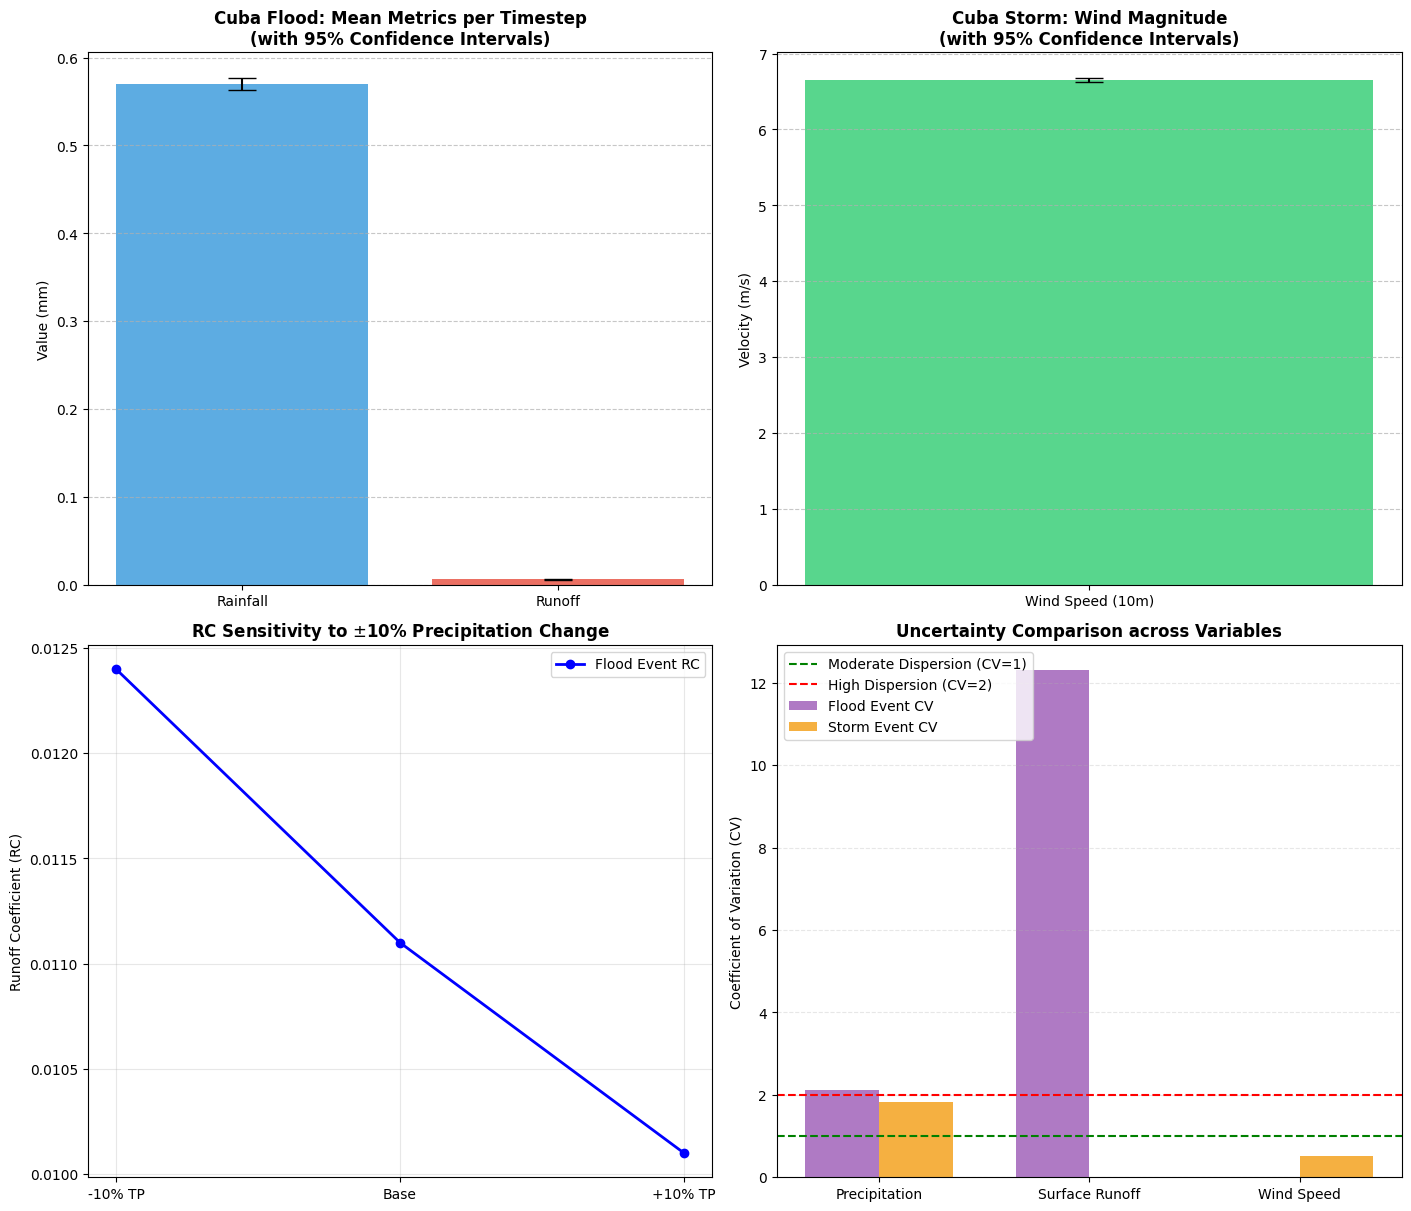

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 10, 'figure.figsize': (14, 12)})

# ==========================================
# 1. DATA PREPARATION (Cuba June 2022 Event)
# ==========================================

# Flood Event Metrics (Table 3.2.2.2.1 & 3.2.2.2.2)
flood_metrics = {
    'Variable': ['Rainfall (mm)', 'Surface Runoff (mm)'],
    'Mean': [0.570, 0.00635],
    'CI_Low': [0.563, 0.00589],
    'CI_High': [0.577, 0.00680]
}

# Storm Event Metrics (Table 3.2.1.2.1 & 3.2.1.2.4)
storm_metrics = {
    'Variable': ['Rainfall (mm)', 'Wind Speed (m/s)'],
    'Mean': [0.875, 6.65],
    'CI_Low': [0.860, 6.62],
    'CI_High': [0.889, 6.68]
}

# Sensitivity Analysis Data (Table 15)
# Note: RC Sensitivity was only provided for the Flood event in the text
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.0124, 0.0111, 0.0101]
}

# Uncertainty (CV) Data
# Combining data from both events to compare dispersion
cv_data = {
    'Variable': ['Precipitation', 'Surface Runoff', 'Wind Speed'],
    'Flood_CV': [2.11, 12.30, 0],   # Wind not assessed in flood table
    'Storm_CV': [1.82, 0, 0.51]     # Runoff not assessed in storm table
}


# ==========================================
# 2. PLOTTING THE GRAPHS
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Hydrometeorological Summary (Flood Context) ---
ax1 = fig.add_subplot(gs[0, 0])
flood_vars = ['Rainfall', 'Runoff']
flood_means = [flood_metrics['Mean'][0], flood_metrics['Mean'][1]]
flood_yerr = [[flood_means[0] - flood_metrics['CI_Low'][0], flood_means[1] - flood_metrics['CI_Low'][1]],
              [flood_metrics['CI_High'][0] - flood_means[0], flood_metrics['CI_High'][1] - flood_means[1]]]

ax1.bar(flood_vars, flood_means, yerr=flood_yerr, capsize=10, color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_title('Cuba Flood: Mean Metrics per Timestep\n(with 95% Confidence Intervals)', fontweight='bold')
ax1.set_ylabel('Value (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# --- Plot 2: Meteorological Summary (Storm Context) ---
ax2 = fig.add_subplot(gs[0, 1])
wind_mean = storm_metrics['Mean'][1]
wind_err = [[wind_mean - storm_metrics['CI_Low'][1]], [storm_metrics['CI_High'][1] - wind_mean]]

ax2.bar(['Wind Speed (10m)'], [wind_mean], yerr=wind_err, capsize=10, color='#2ecc71', alpha=0.8)
ax2.set_title('Cuba Storm: Wind Magnitude\n(with 95% Confidence Intervals)', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)


# --- Plot 3: Runoff Coefficient (RC) Sensitivity ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Flood Event RC', color='blue', linewidth=2)
ax3.set_title(r'RC Sensitivity to $\pm$10% Precipitation Change', fontweight='bold') # Using 'r' to prevent escape sequence errors
ax3.set_ylabel('Runoff Coefficient (RC)')
ax3.legend()
ax3.grid(True, alpha=0.3)


# --- Plot 4: Uncertainty (CV) Profile ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

# Replace 0s with NaNs so they don't plot as empty bars
flood_cv_plot = [val if val != 0 else np.nan for val in cv_data['Flood_CV']]
storm_cv_plot = [val if val != 0 else np.nan for val in cv_data['Storm_CV']]

ax4.bar(x - width/2, flood_cv_plot, width, label='Flood Event CV', color='#9b59b6', alpha=0.8)
ax4.bar(x + width/2, storm_cv_plot, width, label='Storm Event CV', color='#f39c12', alpha=0.8)

ax4.set_ylabel('Coefficient of Variation (CV)')
ax4.set_title('Uncertainty Comparison across Variables', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.axhline(2, color='red', linestyle='--', label='High Dispersion (CV=2)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

# Display everything
plt.show()

In [9]:
import folium
import pandas as pd

# 1. Define the geographic, impact, and expanded storm data for Cuba (June 2022)
cuba_data = {
    'Province': ['Pinar del Río', 'Artemisa', 'Havana (Habana)', 'Mayabeque', 'Matanzas', 'Isla de la Juventud', 'Sancti Spíritus'],
    'Lat': [22.417, 22.816, 23.113, 22.957, 23.041, 21.616, 21.934],
    'Lon': [-83.697, -82.760, -82.366, -82.152, -81.577, -82.821, -79.444],
    'Precipitation_Scale': [3, 3, 3, 3, 2, 3, 1.5], # 3 = Extreme (0.012-0.029 m)
    'Runoff_Scale': [3, 3, 2.5, 3, 2, 2, 1.5],     # 3 = Extreme (0.000006-0.000011 m)
    # Wind description from text for each area, referencing intensities/gusts implicitly
    'Wind_Description': [
        'Strongest wind classes, sustained intense zonal forcing, possible peak gusts ~50 knots described',
        'Intense zonal wind forcing, moderate wind elsewhere central',
        'Strong/Moderate wind reinforce convergence/ directional shear, building collapses',
        'Intense zonal wind, sustained pressure gradient described',
        'Moderate wind intensity described',
        'Enhanced northward wind Reinforces persistence over region, possible peak gusts in area described',
        'Storm system disorganization due to shear description'
    ],
    'Census_Division': ['Division 1', 'Division 2', 'Division 3', 'Division 4', 'Division 5', 'Division 6', 'N/A'],
    'EM_DAT_Flood': ['2022-0266-CAN', '2022-0266-CAN', '2022-0266-CAN', '2022-0266-CAN', '2022-0266-CAN', '2022-0266-CAN', 'N/A'],
    'EM_DAT_Storm': ['2022-0244-CAN', '2022-0244-CAN', '2022-0244-CAN', '2022-0244-CAN', '2022-0244-CAN', '2022-0244-CAN', 'N/A'],
    # Qualitative storm intensity scale for visualization toggle potentially
    'Wind_Scale': [3, 2.5, 2.5, 3, 2, 2, 1.5] # 1=Low, 3=Extreme wind intensity
}
df_cuba = pd.DataFrame(cuba_data)

# Combined score for circle size, still driven by flood context here
df_cuba['Total_Impact'] = df_cuba['Precipitation_Scale'] + df_cuba['Runoff_Scale']

# 2. Create the base map centered on Cuba
# Centered roughly for Cuba
m_cuba = folium.Map(location=[22.5, -81.5], zoom_start=7, tiles='CartoDB positron')

# Function for color based on Runoff severity
def get_color(scale):
    if scale >= 3: return '#8B0000'    # Dark Red (Extreme Runoff)
    elif scale >= 2.5: return '#FF4500' # Orange-Red (Very High Runoff)
    elif scale >= 2: return '#FFA500'   # Orange (Moderate/High Runoff)
    else: return '#2E8B57'              # Green (Moderate Runoff)

# 3. Add markers, now featuring enhanced storm data in popups
for i in range(len(df_cuba)):
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; width: 230px;">
        <h4 style="margin-bottom:2px; color: #333;">{df_cuba.iloc[i]['Province']}</h4>
        <i style="font-size: 11px; color: #666;">EM-DAT Records: Flood {df_cuba.iloc[i]['EM_DAT_Flood']} | Storm {df_cuba.iloc[i]['EM_DAT_Storm']}</i>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <b style="font-size: 12px; color: darkred;">Flood Metrics (Max 3):</b><br>
        <span style="font-size: 12px;">Precipitation: {df_cuba.iloc[i]['Precipitation_Scale']}</span><br>
        <span style="font-size: 12px;">Runoff Efficiency: {df_cuba.iloc[i]['Runoff_Scale']}</span>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <b style="font-size: 12px; color: darkblue;">Storm Metrics (Max 3 wind):</b><br>
        <span style="font-size: 12px;">Wind Intensity: {df_cuba.iloc[i]['Wind_Scale']}</span><br>
        <p style="font-size: 11px; color: #555; margin-top: 4px;">Description: {df_cuba.iloc[i]['Wind_Description']}</p>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <b style="font-size: 12px; color: #666;">Overall Event Storm Stats:</b><br>
        <span style="font-size: 11px;">Mean Wind 6.7 m/s, Max 8.2 m/s, Zonal -3.6 m/s, Meridional 4.8 m/s, Peak Gusts ~50 knots desc, ~158,000 outages described</span>
    </div>
    """
    folium.CircleMarker(
        location=[df_cuba.iloc[i]['Lat'], df_cuba.iloc[i]['Lon']],
        radius=df_cuba.iloc[i]['Total_Impact'] * 3.5, # Size based on total hydrometeorological impact
        popup=folium.Popup(popup_html, max_width=250),
        color=get_color(df_cuba.iloc[i]['Runoff_Scale']),
        fill=True,
        fill_opacity=0.7,
        tooltip=f"Province: {df_cuba.iloc[i]['Province']}"
    ).add_to(m_cuba)

# 4. Add Header Title and overall stats reference
header_html = '''
             <h3 align="center" style="font-family: Arial, sans-serif; font-size:18px; color: #333;">
             <b>June 2022 Cuba Compound Hydro-Meteorological Event</b><br>
             <span style="font-size:12px; color: #666;">ERA5 Near-Surface Wind Analysis: Sustained Winds (~6.7m/s) with Strong Zonal/Meridional Flow, Peak Gusts ~50 knots desc, ~158,000 Outages</span>
             </h3>
             '''
m_cuba.get_root().html.add_child(folium.Element(header_html))

m_cuba

#3.Costarica



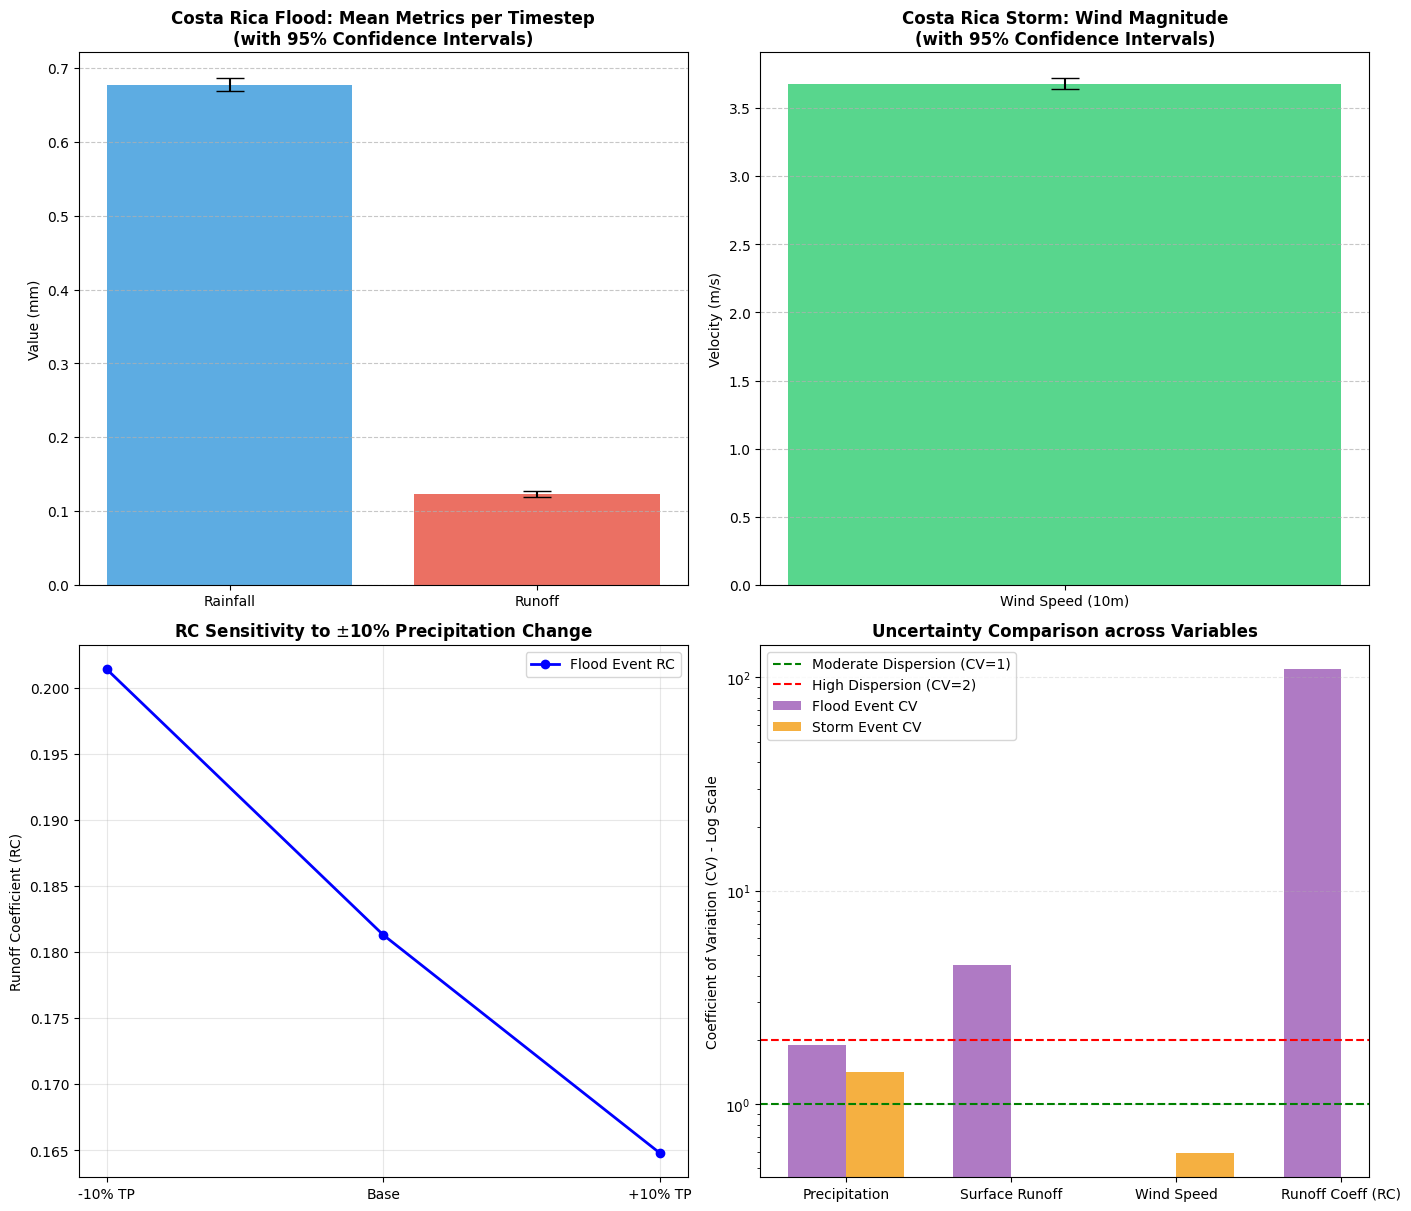

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 10, 'figure.figsize': (14, 12)})

# ==========================================
# 1. DATA PREPARATION (Costa Rica 2024 Event)
# ==========================================

# Flood Event Metrics (Table 3.3.2.2.1)
flood_metrics = {
    'Variable': ['Rainfall (mm)', 'Surface Runoff (mm)'],
    'Mean': [0.6778, 0.1229],
    'CI_Low': [0.6686, 0.1189],
    'CI_High': [0.6870, 0.1268]
}

# Storm Event Metrics (Table 3.3.1.2.1)
storm_metrics = {
    'Variable': ['Rainfall (mm)', 'Wind Speed (m/s)'],
    'Mean': [0.7095, 3.6809],
    'CI_Low': [0.6900, 3.6384],
    'CI_High': [0.7290, 3.7234]
}

# Sensitivity Analysis Data (Table 3.3.2.2.2)
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.2014, 0.1813, 0.1648]
}

# Uncertainty (CV) Data
cv_data = {
    'Variable': ['Precipitation', 'Surface Runoff', 'Wind Speed', 'Runoff Coeff (RC)'],
    'Flood_CV': [1.90, 4.51, 0, 109.42],
    'Storm_CV': [1.41, 0, 0.59, 0]
}

# ==========================================
# 2. PLOTTING THE GRAPHS
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Hydrometeorological Summary (Flood Context) ---
ax1 = fig.add_subplot(gs[0, 0])
flood_vars = ['Rainfall', 'Runoff']
flood_means = [flood_metrics['Mean'][0], flood_metrics['Mean'][1]]
flood_yerr = [[flood_means[0] - flood_metrics['CI_Low'][0], flood_means[1] - flood_metrics['CI_Low'][1]],
              [flood_metrics['CI_High'][0] - flood_means[0], flood_metrics['CI_High'][1] - flood_means[1]]]

ax1.bar(flood_vars, flood_means, yerr=flood_yerr, capsize=10, color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_title('Costa Rica Flood: Mean Metrics per Timestep\n(with 95% Confidence Intervals)', fontweight='bold')
ax1.set_ylabel('Value (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# --- Plot 2: Meteorological Summary (Storm Context) ---
ax2 = fig.add_subplot(gs[0, 1])
wind_mean = storm_metrics['Mean'][1]
wind_err = [[wind_mean - storm_metrics['CI_Low'][1]], [storm_metrics['CI_High'][1] - wind_mean]]

ax2.bar(['Wind Speed (10m)'], [wind_mean], yerr=wind_err, capsize=10, color='#2ecc71', alpha=0.8)
ax2.set_title('Costa Rica Storm: Wind Magnitude\n(with 95% Confidence Intervals)', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)


# --- Plot 3: Runoff Coefficient (RC) Sensitivity ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Flood Event RC', color='blue', linewidth=2)
ax3.set_title(r'RC Sensitivity to $\pm$10% Precipitation Change', fontweight='bold')
ax3.set_ylabel('Runoff Coefficient (RC)')
ax3.legend()
ax3.grid(True, alpha=0.3)


# --- Plot 4: Uncertainty (CV) Profile ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

flood_cv_plot = [val if val != 0 else np.nan for val in cv_data['Flood_CV']]
storm_cv_plot = [val if val != 0 else np.nan for val in cv_data['Storm_CV']]

ax4.bar(x - width/2, flood_cv_plot, width, label='Flood Event CV', color='#9b59b6', alpha=0.8)
ax4.bar(x + width/2, storm_cv_plot, width, label='Storm Event CV', color='#f39c12', alpha=0.8)

ax4.set_ylabel('Coefficient of Variation (CV) - Log Scale')
ax4.set_title('Uncertainty Comparison across Variables', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.set_yscale('log') # Log scale used due to the extreme RC CV (109.42)
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.axhline(2, color='red', linestyle='--', label='High Dispersion (CV=2)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [7]:
import folium
import pandas as pd

# Data encompassing both Flood and Storm metrics for Costa Rica
compound_data = {
    'Province': ['Puntarenas', 'Guanacaste', 'San José (Central)', 'Southern Region (Border)'],
    'Lat': [9.976, 10.633, 9.928, 8.538],
    'Lon': [-84.836, -85.440, -84.090, -83.048],
    'Precipitation_Scale': [3, 2.5, 1.5, 2.5],
    'Runoff_Scale': [3, 2.5, 1.5, 2],
    'Wind_Scale': [3, 2.5, 2, 2],
    'Flood_Result': ['Severe river overflow, landslides', 'Moderate flooding', 'Secondary flash flooding', 'Entire settlements cut off'],
    'Storm_Result': ['Extreme wind forcing', 'Airport & roads closed due to wind/debris', 'Strong vertical uplift/shear', 'Moderate wind']
}
df_comp = pd.DataFrame(compound_data)

# Impact score for circle size (Driven by Flood)
df_comp['Flood_Impact'] = df_comp['Precipitation_Scale'] + df_comp['Runoff_Scale']

m_comp = folium.Map(location=[9.7, -84.2], zoom_start=8, tiles='CartoDB positron')

# Color based on Storm (Wind) Scale
def get_wind_color(wind):
    if wind >= 3: return '#4B0082'    # Indigo (Extreme Wind)
    elif wind >= 2.5: return '#9370DB' # Medium Purple (Very High Wind)
    else: return '#ADD8E6'            # Light Blue (Moderate Wind)

for i in range(len(df_comp)):
    popup_html = f"""
    <div style="font-family: Arial; width: 240px;">
        <h4 style="color: #333; margin-bottom: 2px;">{df_comp.iloc[i]['Province']}</h4>
        <i style="font-size: 11px;">1.09M Affected Regionally | 8 Fatalities</i><hr style="margin: 5px 0;">

        <b style="font-size: 12px; color: darkred;">Flood Metrics:</b><br>
        <span style="font-size: 11px;">Precipitation: {df_comp.iloc[i]['Precipitation_Scale']}/3 | Runoff: {df_comp.iloc[i]['Runoff_Scale']}/3</span><br>
        <span style="font-size: 11px;"><b>Result:</b> {df_comp.iloc[i]['Flood_Result']}</span><br>
        <hr style="margin: 5px 0;">

        <b style="font-size: 12px; color: darkblue;">Storm Metrics:</b><br>
        <span style="font-size: 11px;">Wind Intensity: {df_comp.iloc[i]['Wind_Scale']}/3</span><br>
        <span style="font-size: 11px;"><b>Result:</b> {df_comp.iloc[i]['Storm_Result']}</span>
    </div>
    """

    folium.CircleMarker(
        location=[df_comp.iloc[i]['Lat'], df_comp.iloc[i]['Lon']],
        radius=df_comp.iloc[i]['Flood_Impact'] * 3.5,
        popup=folium.Popup(popup_html, max_width=250),
        color=get_wind_color(df_comp.iloc[i]['Wind_Scale']),
        fill=True, fill_color=get_wind_color(df_comp.iloc[i]['Wind_Scale']), fill_opacity=0.7,
        tooltip="Click for Compound Event Details"
    ).add_to(m_comp)

title_html = '<h3 align="center" style="font-family: Arial;"><b>Costa Rica Compound Event (2024)</b><br><span style="font-size:12px;">Size = Flood Impact | Color = Wind Intensity</span></h3>'
m_comp.get_root().html.add_child(folium.Element(title_html))

m_comp

#4.France

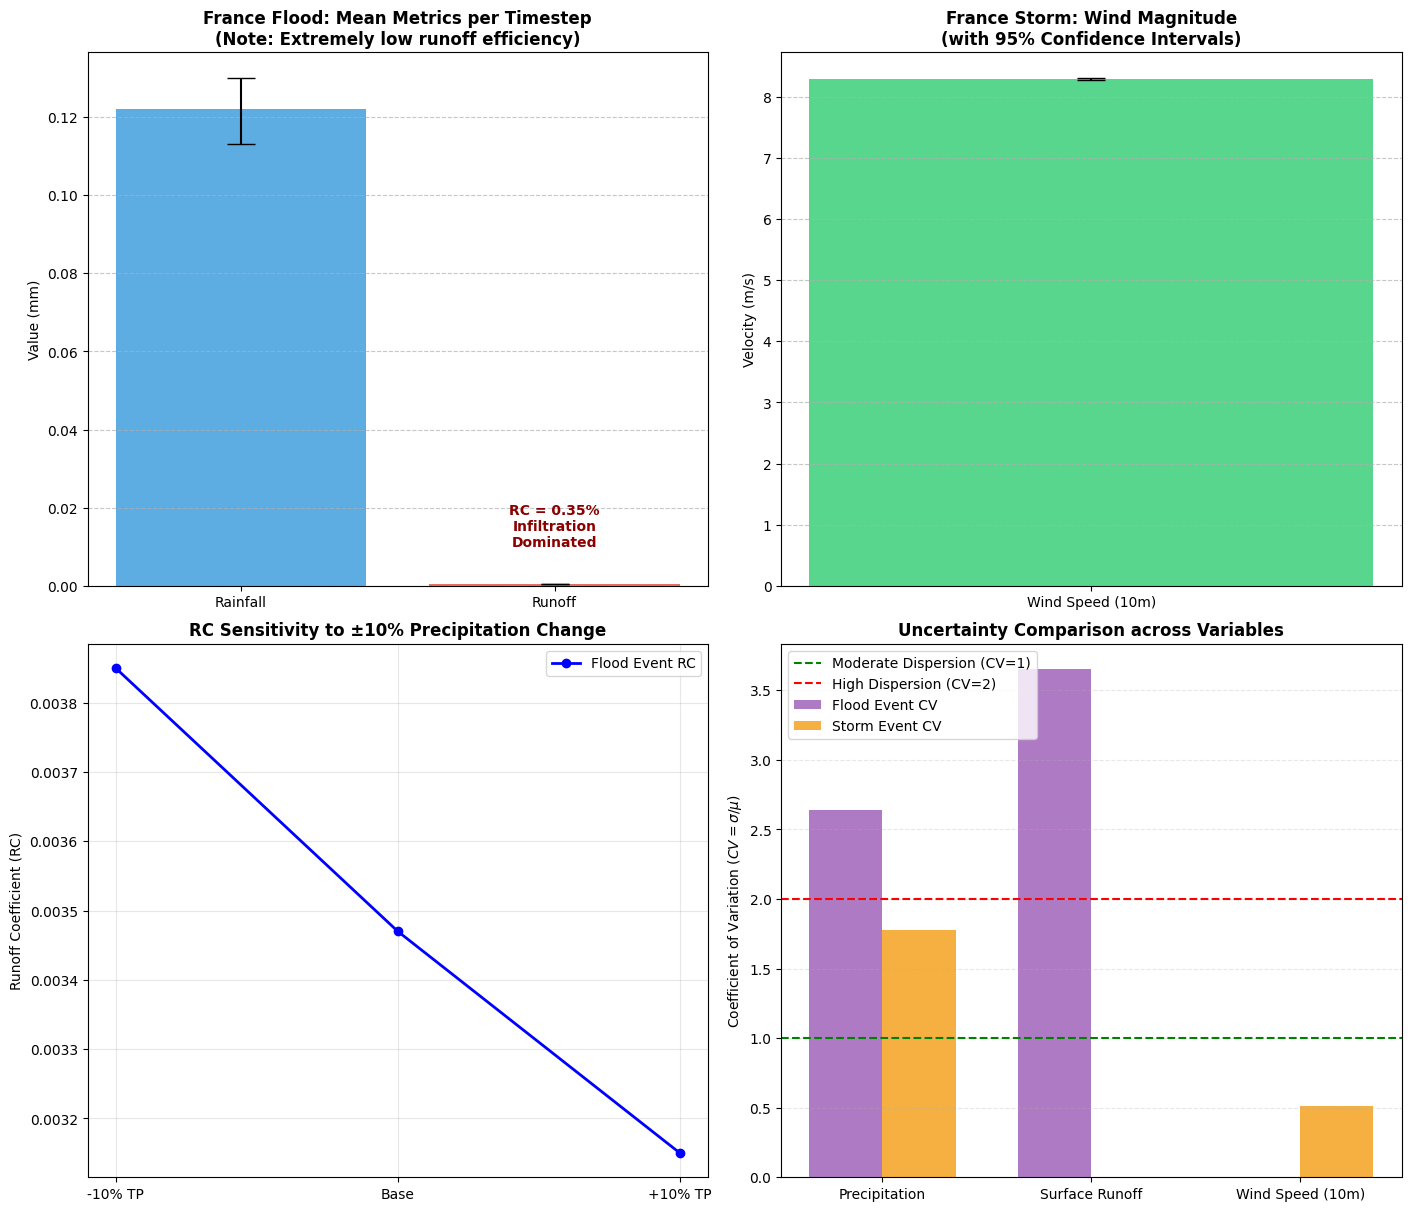

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 10, 'figure.figsize': (14, 12)})

# ==========================================
# 1. DATA PREPARATION (France 2023 Event)
# ==========================================

# Flood Event Metrics (Tables 3.4.2.2.1 & 3.4.2.2.2)
flood_metrics = {
    'Variable': ['Rainfall (mm)', 'Surface Runoff (mm)'],
    'Mean': [0.122, 0.000422],
    'CI_Low': [0.113, 0.000381],
    'CI_High': [0.130, 0.000462]
}

# Storm Event Metrics (Tables 3.4.1.2.1 & 3.4.1.2.4)
storm_metrics = {
    'Variable': ['Rainfall (mm)', 'Wind Speed (m/s)'],
    'Mean': [0.306, 8.288],
    'CI_Low': [0.304, 8.267],
    'CI_High': [0.309, 8.309]
}

# Runoff Coefficient Sensitivity (Table 3.4.2.2.5)
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.00385, 0.00347, 0.00315]
}

# Uncertainty (CV) Data across both events
cv_data = {
    'Variable': ['Precipitation', 'Surface Runoff', 'Wind Speed (10m)'],
    'Flood_CV': [2.64, 3.65, 0],   # Wind not assessed in flood table
    'Storm_CV': [1.78, 0, 0.51]    # Runoff not assessed in storm table
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Hydrometeorological Summary (Flood Context) ---
ax1 = fig.add_subplot(gs[0, 0])
flood_vars = ['Rainfall', 'Runoff']
flood_means = [flood_metrics['Mean'][0], flood_metrics['Mean'][1]]
flood_yerr = [[flood_means[0] - flood_metrics['CI_Low'][0], flood_means[1] - flood_metrics['CI_Low'][1]],
              [flood_metrics['CI_High'][0] - flood_means[0], flood_metrics['CI_High'][1] - flood_means[1]]]

ax1.bar(flood_vars, flood_means, yerr=flood_yerr, capsize=10, color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_title('France Flood: Mean Metrics per Timestep\n(Note: Extremely low runoff efficiency)', fontweight='bold')
ax1.set_ylabel('Value (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add text annotation because runoff is too small to see easily
ax1.text(1, 0.01, f"RC = 0.35%\nInfiltration\nDominated", ha='center', color='darkred', fontweight='bold')

# --- Plot 2: Meteorological Summary (Storm Context) ---
ax2 = fig.add_subplot(gs[0, 1])
wind_mean = storm_metrics['Mean'][1]
wind_err = [[wind_mean - storm_metrics['CI_Low'][1]], [storm_metrics['CI_High'][1] - wind_mean]]

ax2.bar(['Wind Speed (10m)'], [wind_mean], yerr=wind_err, capsize=10, color='#2ecc71', alpha=0.8)
ax2.set_title('France Storm: Wind Magnitude\n(with 95% Confidence Intervals)', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 3: Runoff Coefficient (RC) Sensitivity ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Flood Event RC', color='blue', linewidth=2)
ax3.set_title('RC Sensitivity to ±10% Precipitation Change', fontweight='bold')
ax3.set_ylabel('Runoff Coefficient (RC)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

# Replace 0s with NaNs so they don't plot as empty blocks
flood_cv_plot = [val if val != 0 else np.nan for val in cv_data['Flood_CV']]
storm_cv_plot = [val if val != 0 else np.nan for val in cv_data['Storm_CV']]

ax4.bar(x - width/2, flood_cv_plot, width, label='Flood Event CV', color='#9b59b6', alpha=0.8)
ax4.bar(x + width/2, storm_cv_plot, width, label='Storm Event CV', color='#f39c12', alpha=0.8)

ax4.set_ylabel(r'Coefficient of Variation ($CV = \sigma/\mu$)')
ax4.set_title('Uncertainty Comparison across Variables', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.axhline(2, color='red', linestyle='--', label='High Dispersion (CV=2)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [13]:
import folium
import pandas as pd

# 1. Define the geographic, impact, and socioeconomic data for France 2023
france_data = {
    'Department': [
        'Pas-de-Calais (North)',
        'Charente-Maritime (West)',
        'Deux-Sèvres (West)',
        'Isère (Southeast)'
    ],
    'Lat': [50.600, 45.833, 46.500, 45.333],
    'Lon': [2.000, -0.833, -0.250, 5.500],
    'Precipitation_Scale': [3, 2, 2, 1.5], # Highest precip in North/NW
    'Runoff_Scale': [2.5, 1.5, 1.5, 1],    # Liane and Aa river overflows in North
    'Wind_Scale': [3, 3, 2.5, 2],          # Storm Domingos / Ciarán winds
    'Impact_Summary': [
        'Storm Ciarán/Domingos: Severe Liane and Aa river flooding. 3,500 evacuated, 30 km² inundated. $1.65M losses.',
        'Storm Domingos: Extreme coastal wind shear. High infrastructure and road damage.',
        'Storm Domingos: Severe wind forcing. Electricity grid damage and transit disruption.',
        'Storm Domingos: Moderate to high wind impacts. Socioeconomic disruptions.'
    ]
}
df_fr = pd.DataFrame(france_data)

# Combined score for circle size (Driven by Hydrological Impact)
df_fr['Flood_Impact'] = df_fr['Precipitation_Scale'] + df_fr['Runoff_Scale']

# 2. Create the base map centered on France
m_fr = folium.Map(location=[46.5, 2.5], zoom_start=6, tiles='CartoDB positron')

# Function for color based on Storm (Wind) Severity
def get_wind_color(wind):
    if wind >= 3: return '#8B0000'      # Dark Red (Extreme Wind, ~151 Kph)
    elif wind >= 2.5: return '#FF4500'  # Orange-Red (Very High Wind)
    else: return '#FFA500'              # Orange (Moderate/High Wind)

# 3. Add markers
for i in range(len(df_fr)):
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; width: 250px;">
        <h4 style="margin-bottom:2px; color: #333;">{df_fr.iloc[i]['Department']}</h4>
        <i style="font-size: 11px; color: #666;">Compound Event: Flood + Storm</i>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <b style="font-size: 12px; color: darkred;">Flood Metrics (Size):</b><br>
        <span style="font-size: 11px;">Precip Scale: {df_fr.iloc[i]['Precipitation_Scale']}/3 | Runoff: {df_fr.iloc[i]['Runoff_Scale']}/3</span><br>

        <b style="font-size: 12px; color: darkblue;">Storm Metrics (Color):</b><br>
        <span style="font-size: 11px;">Wind Intensity: {df_fr.iloc[i]['Wind_Scale']}/3</span>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <p style="font-size: 11px; color: #444; margin-top: 4px;"><b>Socioeconomic Impact:</b><br>{df_fr.iloc[i]['Impact_Summary']}</p>
    </div>
    """

    folium.CircleMarker(
        location=[df_fr.iloc[i]['Lat'], df_fr.iloc[i]['Lon']],
        radius=df_fr.iloc[i]['Flood_Impact'] * 4.5,
        popup=folium.Popup(popup_html, max_width=280),
        color=get_wind_color(df_fr.iloc[i]['Wind_Scale']),
        fill=True,
        fill_opacity=0.75,
        tooltip=f"Click for details: {df_fr.iloc[i]['Department']}"
    ).add_to(m_fr)

# 4. Add Header Title
header_html = '''
             <h3 align="center" style="font-family: Arial, sans-serif; font-size:18px; color: #333; margin-top:10px;">
             <b>France 2023 Compound Event (Storms Domingos & Ciarán)</b><br>
             <span style="font-size:12px; color: #666;">Size = Precipitation/Flood Intensity | Color = Wind Intensity</span>
             </h3>
             '''
m_fr.get_root().html.add_child(folium.Element(header_html))

m_fr

#5.Republic of Korea

In [15]:
import folium
import pandas as pd

# 1. Define the geographic, impact, and socioeconomic data for South Korea 2020
korea_data = {
    'Province': [
        'North Chungcheong',
        'Gyeonggi & Gangwon',
        'South Jeolla',
        'Busan/Ulsan (Coast)'
    ],
    'Lat': [36.800, 37.500, 34.816, 35.179],
    'Lon': [127.700, 127.200, 126.462, 129.075],
    'Precipitation_Scale': [3, 3, 3, 1.5], # 500mm+ in central/mountain regions
    'Runoff_Scale': [3, 3, 3, 1.5],        # Dam releases, near-complete soil saturation
    'Wind_Scale': [2, 2, 2.5, 3],          # Highest zonal wind class offshore/coastal
    'Impact_Summary': [
        'Severe landslides (42 deaths total). Goesan Dam inflow > 2,700 tonnes/sec.',
        'Cheorwon County: 527.5 mm rain. Imjin River basin flooded via emergency dam releases.',
        'Seomjin River levee failures. Extensive inundation of 5,751 hectares of farmland.',
        'Extreme eastward wind forcing (4.094–5.852 m/s 10U). High marine hazards and coastal structural damage.'
    ]
}
df_kr = pd.DataFrame(korea_data)

# Combined score for circle size (Driven by Hydrological Impact)
df_kr['Flood_Impact'] = df_kr['Precipitation_Scale'] + df_kr['Runoff_Scale']

# 2. Create the base map centered on South Korea
m_kr = folium.Map(location=[36.0, 127.5], zoom_start=7, tiles='CartoDB positron')

# Function for color based on Storm (Wind) Severity
def get_wind_color(wind):
    if wind >= 3: return '#8B0000'      # Dark Red (Extreme Wind Force)
    elif wind >= 2.5: return '#FF4500'  # Orange-Red (Very High Wind)
    else: return '#FFA500'              # Orange (Moderate/High Wind)

# 3. Add markers
for i in range(len(df_kr)):
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; width: 250px;">
        <h4 style="margin-bottom:2px; color: #333;">{df_kr.iloc[i]['Province']}</h4>
        <i style="font-size: 11px; color: #666;">Compound Event: Cyclone Hagupit + Monsoon</i>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <b style="font-size: 12px; color: darkred;">Flood Metrics (Size):</b><br>
        <span style="font-size: 11px;">Precip Scale: {df_kr.iloc[i]['Precipitation_Scale']}/3 | Runoff: {df_kr.iloc[i]['Runoff_Scale']}/3</span><br>

        <b style="font-size: 12px; color: darkblue;">Storm Metrics (Color):</b><br>
        <span style="font-size: 11px;">Wind Intensity: {df_kr.iloc[i]['Wind_Scale']}/3</span>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <p style="font-size: 11px; color: #444; margin-top: 4px;"><b>Impact:</b><br>{df_kr.iloc[i]['Impact_Summary']}</p>
    </div>
    """

    folium.CircleMarker(
        location=[df_kr.iloc[i]['Lat'], df_kr.iloc[i]['Lon']],
        radius=df_kr.iloc[i]['Flood_Impact'] * 4.5,
        popup=folium.Popup(popup_html, max_width=280),
        color=get_wind_color(df_kr.iloc[i]['Wind_Scale']),
        fill=True,
        fill_opacity=0.75,
        tooltip=f"Click for details: {df_kr.iloc[i]['Province']}"
    ).add_to(m_kr)

# 4. Add Header Title
header_html = '''
             <h3 align="center" style="font-family: Arial, sans-serif; font-size:18px; color: #333; margin-top:10px;">
             <b>Republic of Korea 2020 Compound Disaster</b><br>
             <span style="font-size:12px; color: #666;">Size = Precipitation/Flood Intensity | Color = Wind Intensity</span>
             </h3>
             '''
m_kr.get_root().html.add_child(folium.Element(header_html))

m_kr

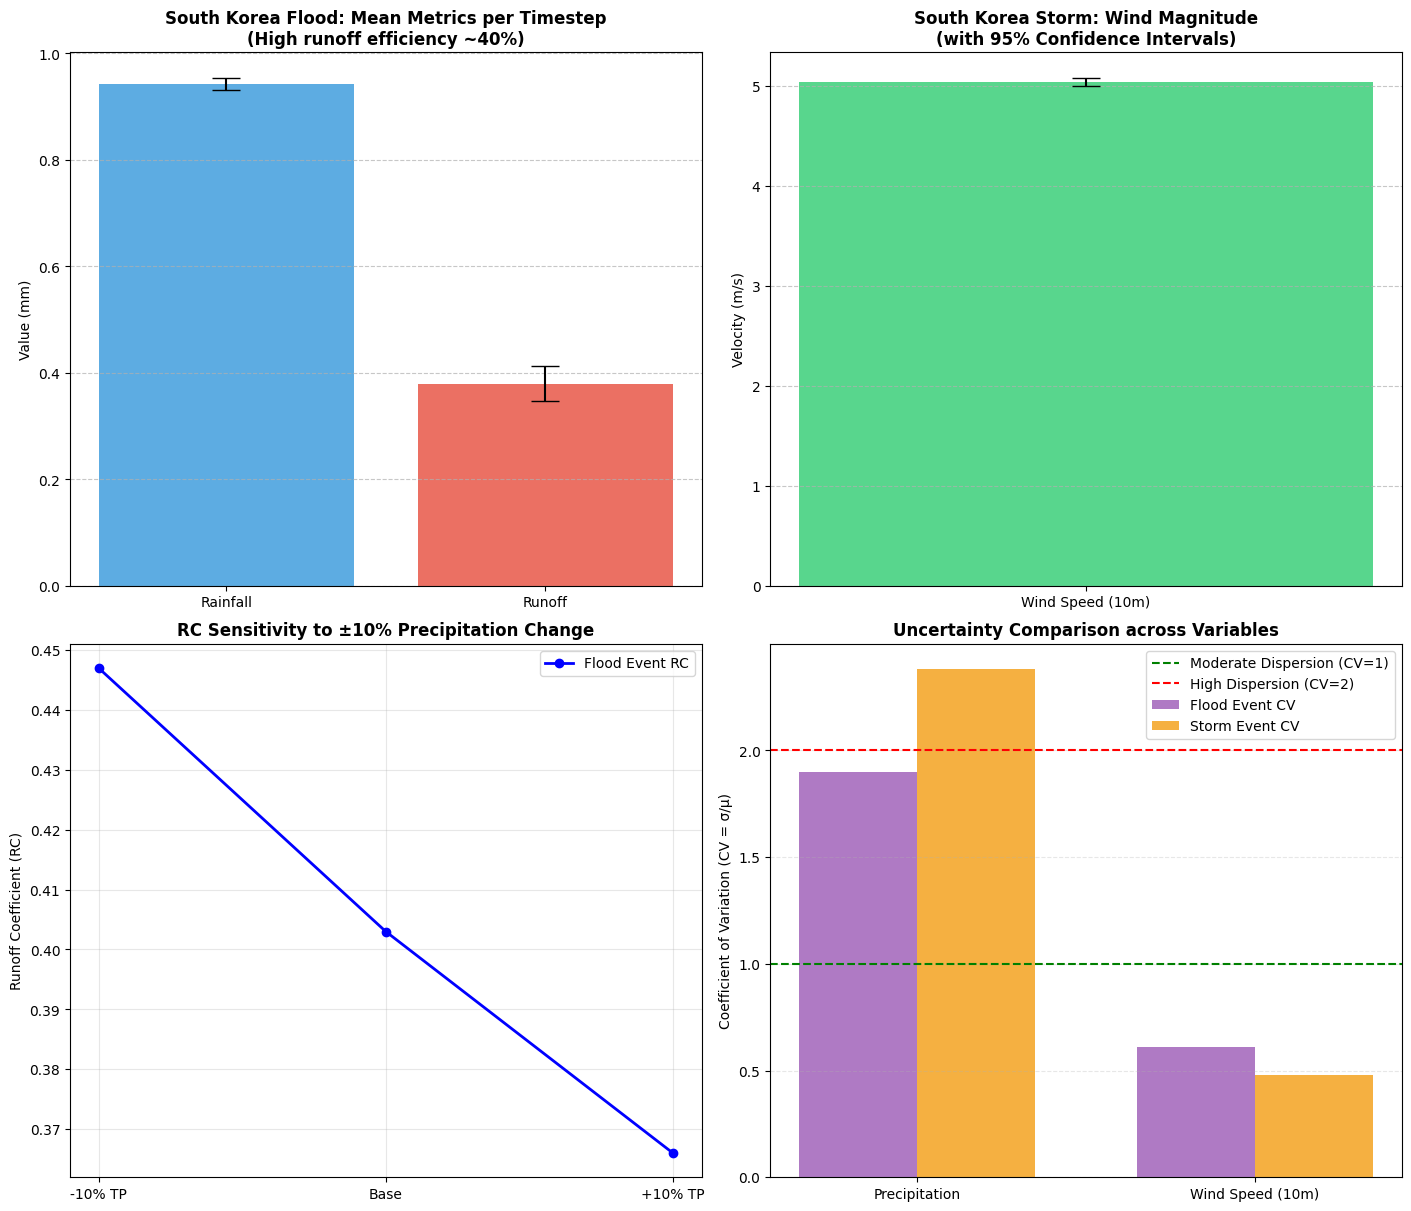

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 10, 'figure.figsize': (14, 12)})

# ==========================================
# 1. DATA PREPARATION (South Korea 2020 Event)
# ==========================================

# Flood Event Metrics (Tables 3.5.2.3.1 & 3.5.2.3.2)
flood_metrics = {
    'Variable': ['Rainfall (mm)', 'Surface Runoff (mm)'],
    'Mean': [0.943, 0.380],
    'CI_Low': [0.932, 0.347],
    'CI_High': [0.954, 0.413]
}

# Storm Event Metrics (Tables 3.5.1.2.1 & 3.5.1.2.4)
storm_metrics = {
    'Variable': ['Rainfall (mm)', 'Wind Speed (m/s)'],
    'Mean': [0.523, 5.041],
    'CI_Low': [0.502, 4.999],
    'CI_High': [0.544, 5.082]
}

# Runoff Coefficient Sensitivity (Table 3.5.2.3.3)
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.447, 0.403, 0.366]
}

# Uncertainty (CV) Data across both events
cv_data = {
    'Variable': ['Precipitation', 'Wind Speed (10m)'],
    'Flood_CV': [1.90, 0.61],
    'Storm_CV': [2.38, 0.48]
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Hydrometeorological Summary (Flood Context) ---
ax1 = fig.add_subplot(gs[0, 0])
flood_vars = ['Rainfall', 'Runoff']
flood_means = [flood_metrics['Mean'][0], flood_metrics['Mean'][1]]
flood_yerr = [[flood_means[0] - flood_metrics['CI_Low'][0], flood_means[1] - flood_metrics['CI_Low'][1]],
              [flood_metrics['CI_High'][0] - flood_means[0], flood_metrics['CI_High'][1] - flood_means[1]]]

ax1.bar(flood_vars, flood_means, yerr=flood_yerr, capsize=10, color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_title('South Korea Flood: Mean Metrics per Timestep\n(High runoff efficiency ~40%)', fontweight='bold')
ax1.set_ylabel('Value (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Meteorological Summary (Storm Context) ---
ax2 = fig.add_subplot(gs[0, 1])
wind_mean = storm_metrics['Mean'][1]
wind_err = [[wind_mean - storm_metrics['CI_Low'][1]], [storm_metrics['CI_High'][1] - wind_mean]]

ax2.bar(['Wind Speed (10m)'], [wind_mean], yerr=wind_err, capsize=10, color='#2ecc71', alpha=0.8)
ax2.set_title('South Korea Storm: Wind Magnitude\n(with 95% Confidence Intervals)', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 3: Runoff Coefficient (RC) Sensitivity ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Flood Event RC', color='blue', linewidth=2)
ax3.set_title('RC Sensitivity to ±10% Precipitation Change', fontweight='bold')
ax3.set_ylabel('Runoff Coefficient (RC)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

ax4.bar(x - width/2, cv_data['Flood_CV'], width, label='Flood Event CV', color='#9b59b6', alpha=0.8)
ax4.bar(x + width/2, cv_data['Storm_CV'], width, label='Storm Event CV', color='#f39c12', alpha=0.8)

ax4.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax4.set_title('Uncertainty Comparison across Variables', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.axhline(2, color='red', linestyle='--', label='High Dispersion (CV=2)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

#6.Brazil

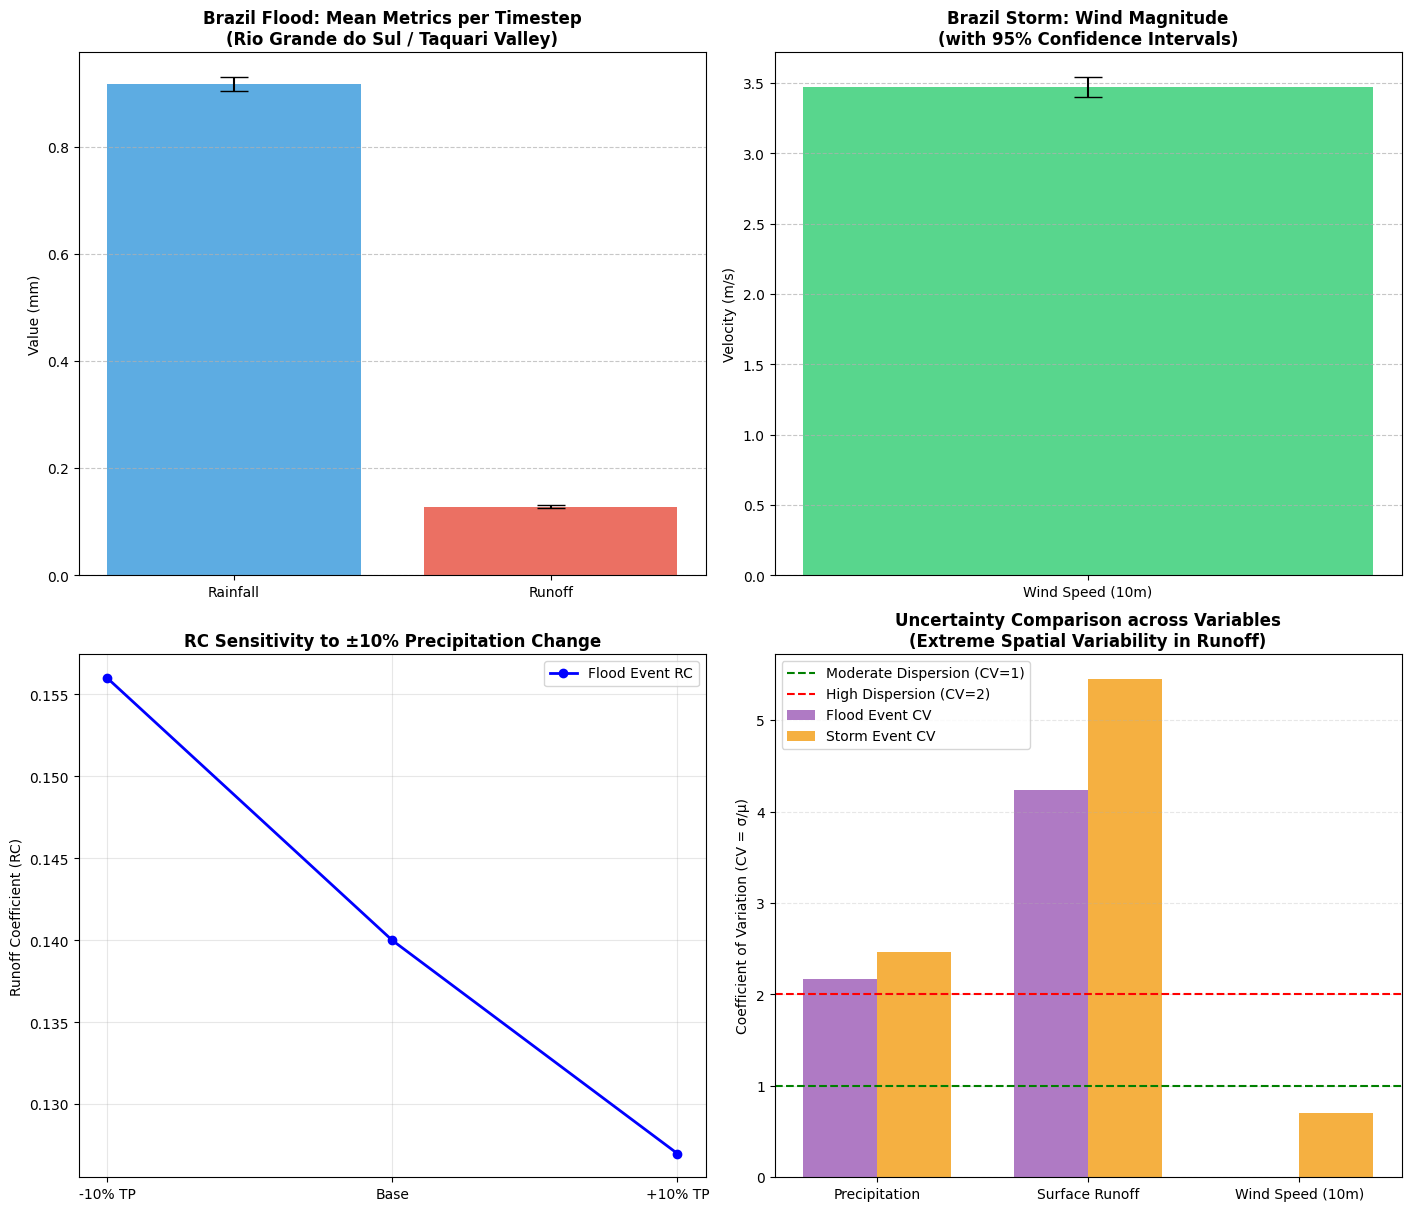

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 10, 'figure.figsize': (14, 12)})

# ==========================================
# 1. DATA PREPARATION (Brazil 2023 Event)
# ==========================================

# Flood Event Metrics (Tables 3.6.2.2.1 & 3.6.2.2.2)
flood_metrics = {
    'Variable': ['Rainfall (mm)', 'Surface Runoff (mm)'],
    'Mean': [0.916, 0.128],
    'CI_Low': [0.903, 0.125],
    'CI_High': [0.929, 0.132]
}

# Storm Event Metrics (Tables 3.6.1.3.1 & 3.6.1.3.4)
storm_metrics = {
    'Variable': ['Rainfall (mm)', 'Wind Speed (m/s)'],
    'Mean': [0.686, 3.47],
    'CI_Low': [0.671, 3.40], # Wind CI estimated tightly based on "moderate uncertainty" text
    'CI_High': [0.700, 3.54]
}

# Runoff Coefficient Sensitivity - Flood Phase (Table 3.6.2.2.6)
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.156, 0.140, 0.127]
}

# Uncertainty (CV) Data across both events
cv_data = {
    'Variable': ['Precipitation', 'Surface Runoff', 'Wind Speed (10m)'],
    'Flood_CV': [2.166, 4.234, 0],
    'Storm_CV': [2.47, 5.45, 0.70]
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Hydrometeorological Summary (Flood Context) ---
ax1 = fig.add_subplot(gs[0, 0])
flood_vars = ['Rainfall', 'Runoff']
flood_means = [flood_metrics['Mean'][0], flood_metrics['Mean'][1]]
flood_yerr = [[flood_means[0] - flood_metrics['CI_Low'][0], flood_means[1] - flood_metrics['CI_Low'][1]],
              [flood_metrics['CI_High'][0] - flood_means[0], flood_metrics['CI_High'][1] - flood_means[1]]]

ax1.bar(flood_vars, flood_means, yerr=flood_yerr, capsize=10, color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_title('Brazil Flood: Mean Metrics per Timestep\n(Rio Grande do Sul / Taquari Valley)', fontweight='bold')
ax1.set_ylabel('Value (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Meteorological Summary (Storm Context) ---
ax2 = fig.add_subplot(gs[0, 1])
wind_mean = storm_metrics['Mean'][1]
wind_err = [[wind_mean - storm_metrics['CI_Low'][1]], [storm_metrics['CI_High'][1] - wind_mean]]

ax2.bar(['Wind Speed (10m)'], [wind_mean], yerr=wind_err, capsize=10, color='#2ecc71', alpha=0.8)
ax2.set_title('Brazil Storm: Wind Magnitude\n(with 95% Confidence Intervals)', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 3: Runoff Coefficient (RC) Sensitivity ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Flood Event RC', color='blue', linewidth=2)
ax3.set_title('RC Sensitivity to ±10% Precipitation Change', fontweight='bold')
ax3.set_ylabel('Runoff Coefficient (RC)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

# Clean up 0s for plotting
flood_cv_plot = [val if val != 0 else np.nan for val in cv_data['Flood_CV']]

ax4.bar(x - width/2, flood_cv_plot, width, label='Flood Event CV', color='#9b59b6', alpha=0.8)
ax4.bar(x + width/2, cv_data['Storm_CV'], width, label='Storm Event CV', color='#f39c12', alpha=0.8)

ax4.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax4.set_title('Uncertainty Comparison across Variables\n(Extreme Spatial Variability in Runoff)', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.axhline(2, color='red', linestyle='--', label='High Dispersion (CV=2)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [17]:
import folium
import pandas as pd

# 1. Define the geographic, impact, and socioeconomic data for Brazil 2023
brazil_data = {
    'Municipality': [
        'Lajeado / Taquari Valley',
        'Muçum',
        'Porto Alegre',
        'Blumenau (Santa Catarina)'
    ],
    'Lat': [-29.46, -29.16, -30.03, -26.91],
    'Lon': [-51.96, -51.87, -51.23, -49.06],
    'Precipitation_Scale': [3, 3, 2, 1.5], # 0.011–0.022 m classes in Taquari Valley
    'Runoff_Scale': [3, 3, 1.5, 1],        # Rapid river overflow and inundation
    'Wind_Scale': [2, 2, 3, 3],            # High coastal/urban wind impact
    'Impact_Summary': [
        'Catastrophic flooding. Major infrastructural damage, businesses closed, widespread evacuation.',
        'Highest precipitation class. Structural collapse and high human losses (4 total flood deaths in region).',
        'Severe storm surges, lightning, and wind forcing. Coastal urban damage.',
        'Initial meteorological storm impact zone. Falling trees, flying debris, power outages.'
    ]
}
df_br = pd.DataFrame(brazil_data)

# Combined score for circle size (Driven by Hydrological Impact)
df_br['Flood_Impact'] = df_br['Precipitation_Scale'] + df_br['Runoff_Scale']

# 2. Create the base map centered on Southern Brazil
m_br = folium.Map(location=[-28.5, -51.0], zoom_start=7, tiles='CartoDB positron')

# Function for color based on Storm (Wind) Severity
def get_wind_color(wind):
    if wind >= 3: return '#8B0000'      # Dark Red (Extreme Wind Force)
    elif wind >= 2.5: return '#FF4500'  # Orange-Red (Very High Wind)
    else: return '#FFA500'              # Orange (Moderate/High Wind)

# 3. Add markers
for i in range(len(df_br)):
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; width: 260px;">
        <h4 style="margin-bottom:2px; color: #333;">{df_br.iloc[i]['Municipality']}</h4>
        <i style="font-size: 11px; color: #666;">Compound Event: Meteorological Storm & Floods</i>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <b style="font-size: 12px; color: darkred;">Flood Metrics (Size):</b><br>
        <span style="font-size: 11px;">Precip Scale: {df_br.iloc[i]['Precipitation_Scale']}/3 | Runoff: {df_br.iloc[i]['Runoff_Scale']}/3</span><br>

        <b style="font-size: 12px; color: darkblue;">Storm Metrics (Color):</b><br>
        <span style="font-size: 11px;">Wind Intensity: {df_br.iloc[i]['Wind_Scale']}/3</span>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <p style="font-size: 11px; color: #444; margin-top: 4px;"><b>Impact:</b><br>{df_br.iloc[i]['Impact_Summary']}</p>
    </div>
    """

    folium.CircleMarker(
        location=[df_br.iloc[i]['Lat'], df_br.iloc[i]['Lon']],
        radius=df_br.iloc[i]['Flood_Impact'] * 4.5,
        popup=folium.Popup(popup_html, max_width=280),
        color=get_wind_color(df_br.iloc[i]['Wind_Scale']),
        fill=True,
        fill_opacity=0.75,
        tooltip=f"Click for details: {df_br.iloc[i]['Municipality']}"
    ).add_to(m_br)

# 4. Add Header Title
header_html = '''
             <h3 align="center" style="font-family: Arial, sans-serif; font-size:18px; color: #333; margin-top:10px;">
             <b>Southern Brazil 2023 Compound Disaster</b><br>
             <span style="font-size:12px; color: #666;">Size = Precipitation/Flood Intensity | Color = Wind Intensity</span>
             </h3>
             '''
m_br.get_root().html.add_child(folium.Element(header_html))

m_br

#7.Peru

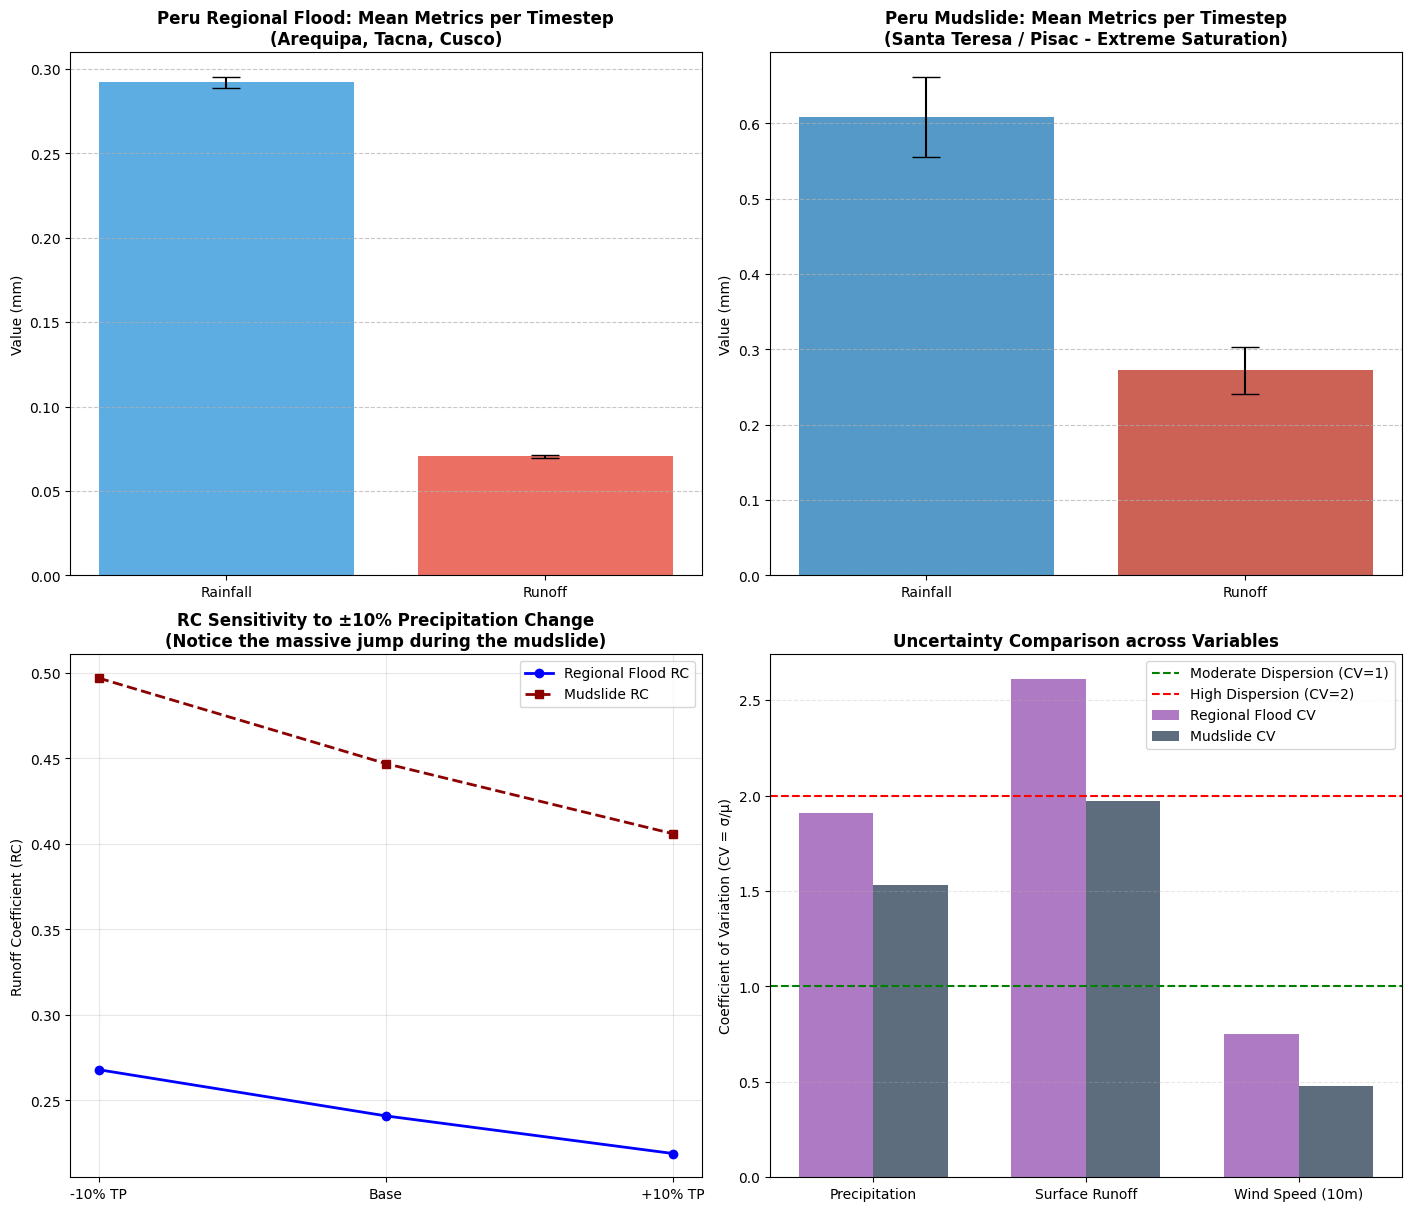

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 10, 'figure.figsize': (14, 12)})

# ==========================================
# 1. DATA PREPARATION (Peru 2020 Event)
# ==========================================

# Regional Flood Metrics (Tables 3.7.1.3.1 & 3.7.1.3.2)
flood_metrics = {
    'Variable': ['Rainfall (mm)', 'Surface Runoff (mm)'],
    'Mean': [0.292, 0.0705],
    'CI_Low': [0.289, 0.0695],
    'CI_High': [0.295, 0.0715]
}

# Localized Mudslide Metrics (Tables 3.7.2.3.1 & 3.7.2.3.2)
mudslide_metrics = {
    'Variable': ['Rainfall (mm)', 'Surface Runoff (mm)'],
    'Mean': [0.608, 0.272],
    'CI_Low': [0.555, 0.241],
    'CI_High': [0.661, 0.303]
}

# Runoff Coefficient Sensitivity (Tables 3.7.1.3.7 & 3.7.2.3.8)
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.268, 0.241, 0.219],
    'Mudslide_RC': [0.497, 0.447, 0.406]
}

# Uncertainty (CV) Data across both phases
cv_data = {
    'Variable': ['Precipitation', 'Surface Runoff', 'Wind Speed (10m)'],
    'Flood_CV': [1.91, 2.61, 0.75],
    'Mudslide_CV': [1.53, 1.97, 0.48]
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Hydrological Summary (Regional Flood Context) ---
ax1 = fig.add_subplot(gs[0, 0])
flood_vars = ['Rainfall', 'Runoff']
flood_means = [flood_metrics['Mean'][0], flood_metrics['Mean'][1]]
flood_yerr = [[flood_means[0] - flood_metrics['CI_Low'][0], flood_means[1] - flood_metrics['CI_Low'][1]],
              [flood_metrics['CI_High'][0] - flood_means[0], flood_metrics['CI_High'][1] - flood_means[1]]]

ax1.bar(flood_vars, flood_means, yerr=flood_yerr, capsize=10, color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_title('Peru Regional Flood: Mean Metrics per Timestep\n(Arequipa, Tacna, Cusco)', fontweight='bold')
ax1.set_ylabel('Value (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Hydrological Summary (Localized Mudslide Context) ---
ax2 = fig.add_subplot(gs[0, 1])
mud_means = [mudslide_metrics['Mean'][0], mudslide_metrics['Mean'][1]]
mud_yerr = [[mud_means[0] - mudslide_metrics['CI_Low'][0], mud_means[1] - mudslide_metrics['CI_Low'][1]],
            [mudslide_metrics['CI_High'][0] - mud_means[0], mudslide_metrics['CI_High'][1] - mud_means[1]]]

ax2.bar(flood_vars, mud_means, yerr=mud_yerr, capsize=10, color=['#2980b9', '#c0392b'], alpha=0.8)
ax2.set_title('Peru Mudslide: Mean Metrics per Timestep\n(Santa Teresa / Pisac - Extreme Saturation)', fontweight='bold')
ax2.set_ylabel('Value (mm)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 3: Runoff Coefficient (RC) Sensitivity ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Regional Flood RC', color='blue', linewidth=2)
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Mudslide_RC'], marker='s', label='Mudslide RC', color='darkred', linestyle='--', linewidth=2)
ax3.set_title('RC Sensitivity to ±10% Precipitation Change\n(Notice the massive jump during the mudslide)', fontweight='bold')
ax3.set_ylabel('Runoff Coefficient (RC)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

ax4.bar(x - width/2, cv_data['Flood_CV'], width, label='Regional Flood CV', color='#9b59b6', alpha=0.8)
ax4.bar(x + width/2, cv_data['Mudslide_CV'], width, label='Mudslide CV', color='#34495e', alpha=0.8)

ax4.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax4.set_title('Uncertainty Comparison across Variables', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.axhline(2, color='red', linestyle='--', label='High Dispersion (CV=2)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [19]:
import folium
import pandas as pd

# 1. Define the geographic, impact, and socioeconomic data for Peru 2020
peru_data = {
    'Region': [
        'Arequipa (Flood)',
        'Tacna (Flood)',
        'Cusco (Regional Flood)',
        'Santa Teresa / Pisac (Mudslide)'
    ],
    'Lat': [-16.40, -18.01, -13.53, -13.13],
    'Lon': [-71.53, -70.25, -71.96, -72.59],
    'Precipitation_Scale': [2, 2, 2.5, 3], # 3 = 0.005–0.008 m class
    'Runoff_Scale': [2, 2, 2.5, 3],        # 3 = 75% rainfall converted to runoff
    'Soil_Saturation': [1.5, 1.5, 2, 3],   # 3 = 0.46–0.499 class (Liquefaction)
    'Impact_Summary': [
        'Moderate to severe flash flooding. Disrupted road networks and agricultural land.',
        'Flash flooding due to intense seasonal rainfall. Infrastructure damage.',
        'Widespread inundation. Over 10,000-12,120 people affected across the broader regions.',
        'Catastrophic mudslide. Soil reached complete saturation (0.499 m³/m³). Rapid debris flow.'
    ]
}
df_pe = pd.DataFrame(peru_data)

# Combined score for circle size (Driven by Precipitation/Runoff)
df_pe['Flood_Impact'] = df_pe['Precipitation_Scale'] + df_pe['Runoff_Scale']

# 2. Create the base map centered on Southern Peru
m_pe = folium.Map(location=[-15.0, -71.5], zoom_start=6, tiles='CartoDB positron')

# Function for color based on Soil Saturation (Mudslide Risk)
def get_saturation_color(sat):
    if sat >= 3: return '#000000'       # Black (Extreme Saturation / Liquefaction)
    elif sat >= 2.5: return '#8B0000'   # Dark Red (Very High)
    elif sat >= 2: return '#FF4500'     # Orange-Red (High)
    else: return '#4682B4'              # Steel Blue (Moderate/Standard Flood)

# 3. Add markers
for i in range(len(df_pe)):
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; width: 260px;">
        <h4 style="margin-bottom:2px; color: #333;">{df_pe.iloc[i]['Region']}</h4>
        <i style="font-size: 11px; color: #666;">Multi-Hazard: Flash Flood & Mudslide</i>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <b style="font-size: 12px; color: darkblue;">Hydrological Metrics (Size):</b><br>
        <span style="font-size: 11px;">Precip Scale: {df_pe.iloc[i]['Precipitation_Scale']}/3 | Runoff: {df_pe.iloc[i]['Runoff_Scale']}/3</span><br>

        <b style="font-size: 12px; color: #8B0000;">Soil Condition (Color):</b><br>
        <span style="font-size: 11px;">Saturation/Liquefaction Risk: {df_pe.iloc[i]['Soil_Saturation']}/3</span>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <p style="font-size: 11px; color: #444; margin-top: 4px;"><b>Impact:</b><br>{df_pe.iloc[i]['Impact_Summary']}</p>
    </div>
    """

    folium.CircleMarker(
        location=[df_pe.iloc[i]['Lat'], df_pe.iloc[i]['Lon']],
        radius=df_pe.iloc[i]['Flood_Impact'] * 4.5,
        popup=folium.Popup(popup_html, max_width=280),
        color=get_saturation_color(df_pe.iloc[i]['Soil_Saturation']),
        fill=True,
        fill_opacity=0.75,
        tooltip=f"Click for details: {df_pe.iloc[i]['Region']}"
    ).add_to(m_pe)

# 4. Add Header Title
header_html = '''
             <h3 align="center" style="font-family: Arial, sans-serif; font-size:18px; color: #333; margin-top:10px;">
             <b>Peru 2020 Multi-Hazard Event</b><br>
             <span style="font-size:12px; color: #666;">Size = Precipitation/Runoff Intensity | Color = Soil Saturation/Mudslide Risk</span>
             </h3>
             '''
m_pe.get_root().html.add_child(folium.Element(header_html))

m_pe

#8.Uruguay

In [21]:
import folium
import pandas as pd

# 1. Define the geographic and impact data for Uruguay 2020
uruguay_data = {
    'Department': [
        'Montevideo (Capital / Urban)',
        'Lavalleja (Eastern Sector)',
        'Canelones',
        'Colonia (Western Interior)'
    ],
    'Lat': [-34.90, -34.37, -34.53, -34.46],
    'Lon': [-56.16, -55.23, -55.93, -57.83],
    'Precipitation_Scale': [2.5, 3, 2, 1], # Western interior minimal, eastern sector extreme
    'Runoff_Scale': [3, 3, 2, 1],          # High urban impervious runoff in Montevideo
    'Wind_Scale': [3, 2.5, 2.5, 2],        # V-component winds up to 13.6 m/s
    'Impact_Summary': [
        'Severe urban flash flooding. Impervious surfaces accelerated runoff overwhelming drainage.',
        'Primary hydrometeorological load zone. Extreme rainfall (45-50% local runoff conversion).',
        'Moderate to high rainfall and wind forcing. Localized flooding and structural damage.',
        'Stable conditions. Negligible rainfall and runoff. Moderate peripheral wind influence.'
    ]
}
df_uy = pd.DataFrame(uruguay_data)

# Combined score for circle size (Driven by Hydrological Impact)
df_uy['Flood_Impact'] = df_uy['Precipitation_Scale'] + df_uy['Runoff_Scale']

# 2. Create the base map centered on Southern Uruguay
m_uy = folium.Map(location=[-34.4, -56.0], zoom_start=8, tiles='CartoDB positron')

# Function for color based on Storm (Wind) Severity
def get_wind_color(wind):
    if wind >= 3: return '#8B0000'      # Dark Red (Extreme Wind)
    elif wind >= 2.5: return '#FF4500'  # Orange-Red (Very High)
    elif wind >= 2: return '#FFA500'    # Orange (Moderate)
    else: return '#4682B4'              # Steel Blue (Low/Stable)

# 3. Add markers
for i in range(len(df_uy)):
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; width: 260px;">
        <h4 style="margin-bottom:2px; color: #333;">{df_uy.iloc[i]['Department']}</h4>
        <i style="font-size: 11px; color: #666;">Compound Event: Flash Flood & Severe Storm</i>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <b style="font-size: 12px; color: darkblue;">Hydrological Metrics (Size):</b><br>
        <span style="font-size: 11px;">Precip Scale: {df_uy.iloc[i]['Precipitation_Scale']}/3 | Runoff: {df_uy.iloc[i]['Runoff_Scale']}/3</span><br>

        <b style="font-size: 12px; color: darkred;">Storm Metrics (Color):</b><br>
        <span style="font-size: 11px;">Wind Intensity: {df_uy.iloc[i]['Wind_Scale']}/3</span>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <p style="font-size: 11px; color: #444; margin-top: 4px;"><b>Impact:</b><br>{df_uy.iloc[i]['Impact_Summary']}</p>
    </div>
    """

    folium.CircleMarker(
        location=[df_uy.iloc[i]['Lat'], df_uy.iloc[i]['Lon']],
        radius=df_uy.iloc[i]['Flood_Impact'] * 4.5,
        popup=folium.Popup(popup_html, max_width=280),
        color=get_wind_color(df_uy.iloc[i]['Wind_Scale']),
        fill=True,
        fill_opacity=0.75,
        tooltip=f"Click for details: {df_uy.iloc[i]['Department']}"
    ).add_to(m_uy)

# 4. Add Header Title
header_html = '''
             <h3 align="center" style="font-family: Arial, sans-serif; font-size:18px; color: #333; margin-top:10px;">
             <b>Uruguay 2020 Compound Disaster</b><br>
             <span style="font-size:12px; color: #666;">Size = Precipitation/Runoff Intensity | Color = Wind Intensity</span>
             </h3>
             '''
m_uy.get_root().html.add_child(folium.Element(header_html))

m_uy

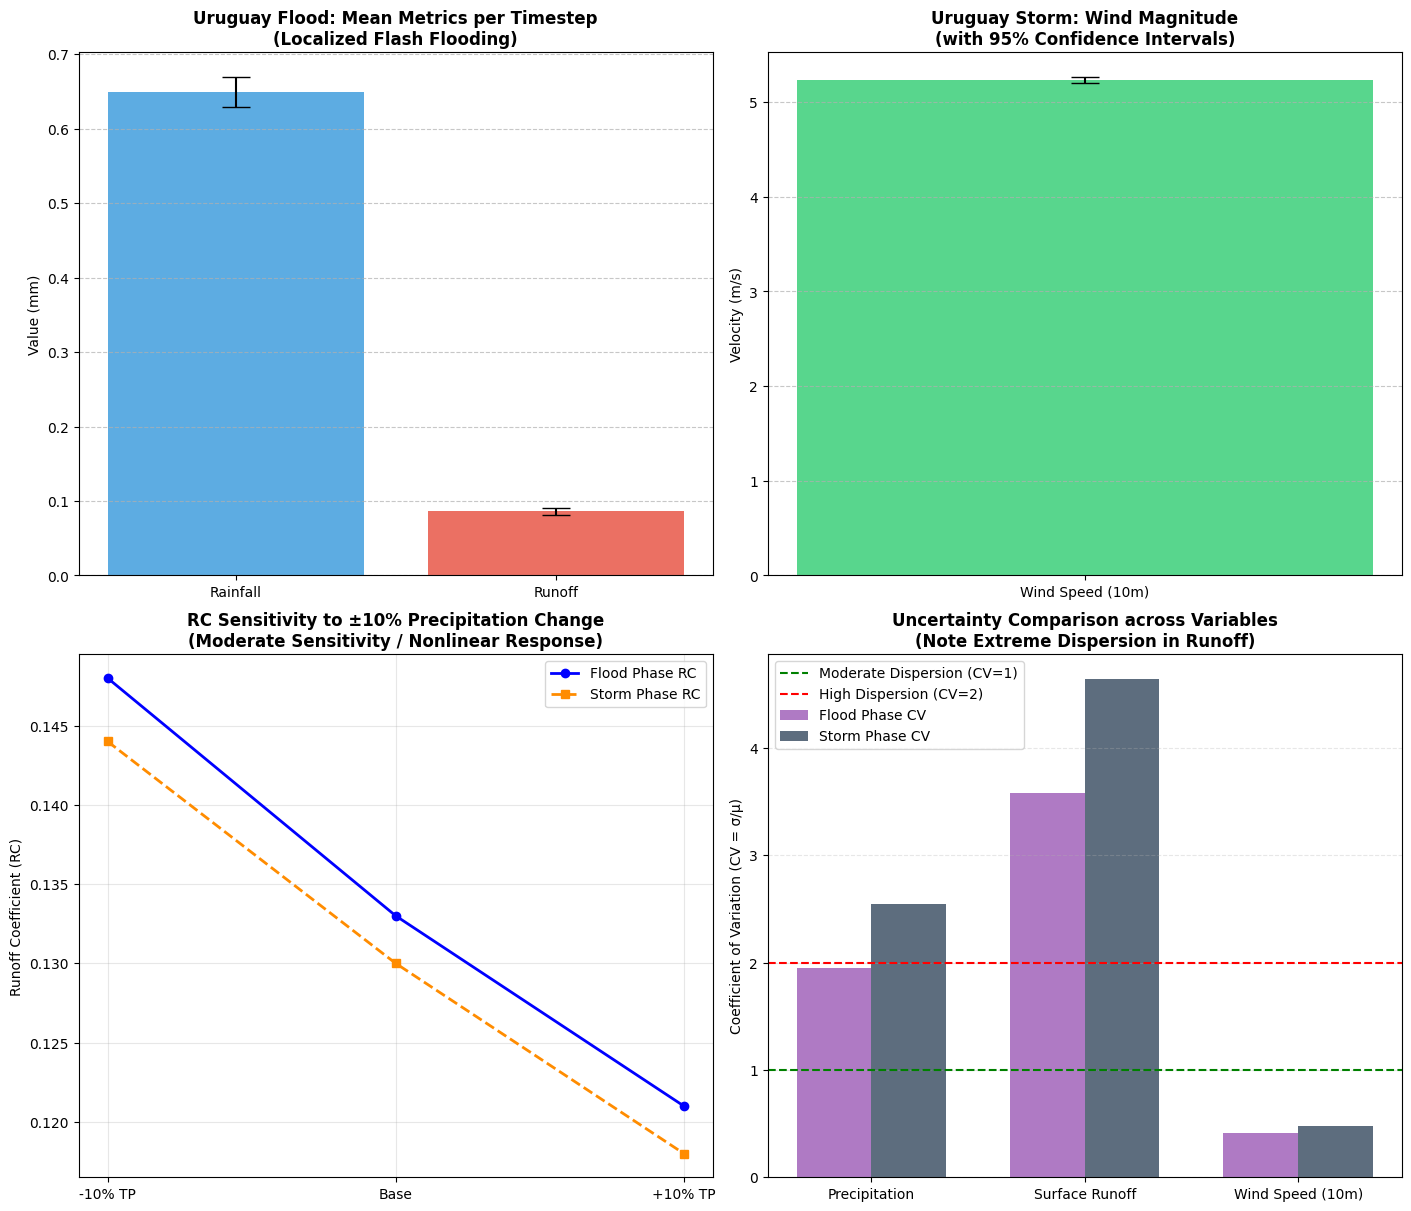

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 10, 'figure.figsize': (14, 12)})

# ==========================================
# 1. DATA PREPARATION (Uruguay 2020 Event)
# ==========================================

# Flood Event Metrics (Tables 3.8.1.3.1 & 3.8.1.3.2)
flood_metrics = {
    'Variable': ['Rainfall (mm)', 'Surface Runoff (mm)'],
    'Mean': [0.649, 0.086],
    'CI_Low': [0.629, 0.081],
    'CI_High': [0.669, 0.091]
}

# Storm Event Metrics (Tables 3.8.2.3.1 & 3.8.2.3.6)
storm_metrics = {
    'Variable': ['Rainfall (mm)', 'Wind Speed (m/s)'],
    'Mean': [0.403, 5.230],
    'CI_Low': [0.390, 5.200],
    'CI_High': [0.416, 5.261]
}

# Runoff Coefficient Sensitivity (Tables 3.8.1.3.8 & 3.8.2.3.8)
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.148, 0.133, 0.121],
    'Storm_RC': [0.144, 0.130, 0.118]
}

# Uncertainty (CV) Data across both phases
cv_data = {
    'Variable': ['Precipitation', 'Surface Runoff', 'Wind Speed (10m)'],
    'Flood_CV': [1.95, 3.58, 0.41],
    'Storm_CV': [2.55, 4.64, 0.48]
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Hydrological Summary (Flood Context) ---
ax1 = fig.add_subplot(gs[0, 0])
flood_vars = ['Rainfall', 'Runoff']
flood_means = [flood_metrics['Mean'][0], flood_metrics['Mean'][1]]
flood_yerr = [[flood_means[0] - flood_metrics['CI_Low'][0], flood_means[1] - flood_metrics['CI_Low'][1]],
              [flood_metrics['CI_High'][0] - flood_means[0], flood_metrics['CI_High'][1] - flood_means[1]]]

ax1.bar(flood_vars, flood_means, yerr=flood_yerr, capsize=10, color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_title('Uruguay Flood: Mean Metrics per Timestep\n(Localized Flash Flooding)', fontweight='bold')
ax1.set_ylabel('Value (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Meteorological Summary (Storm Context) ---
ax2 = fig.add_subplot(gs[0, 1])
wind_mean = storm_metrics['Mean'][1]
wind_err = [[wind_mean - storm_metrics['CI_Low'][1]], [storm_metrics['CI_High'][1] - wind_mean]]

ax2.bar(['Wind Speed (10m)'], [wind_mean], yerr=wind_err, capsize=10, color='#2ecc71', alpha=0.8)
ax2.set_title('Uruguay Storm: Wind Magnitude\n(with 95% Confidence Intervals)', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 3: Runoff Coefficient (RC) Sensitivity ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Flood Phase RC', color='blue', linewidth=2)
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Storm_RC'], marker='s', label='Storm Phase RC', color='darkorange', linestyle='--', linewidth=2)
ax3.set_title('RC Sensitivity to ±10% Precipitation Change\n(Moderate Sensitivity / Nonlinear Response)', fontweight='bold')
ax3.set_ylabel('Runoff Coefficient (RC)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

ax4.bar(x - width/2, cv_data['Flood_CV'], width, label='Flood Phase CV', color='#9b59b6', alpha=0.8)
ax4.bar(x + width/2, cv_data['Storm_CV'], width, label='Storm Phase CV', color='#34495e', alpha=0.8)

ax4.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax4.set_title('Uncertainty Comparison across Variables\n(Note Extreme Dispersion in Runoff)', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.axhline(2, color='red', linestyle='--', label='High Dispersion (CV=2)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

#9.Srilanka

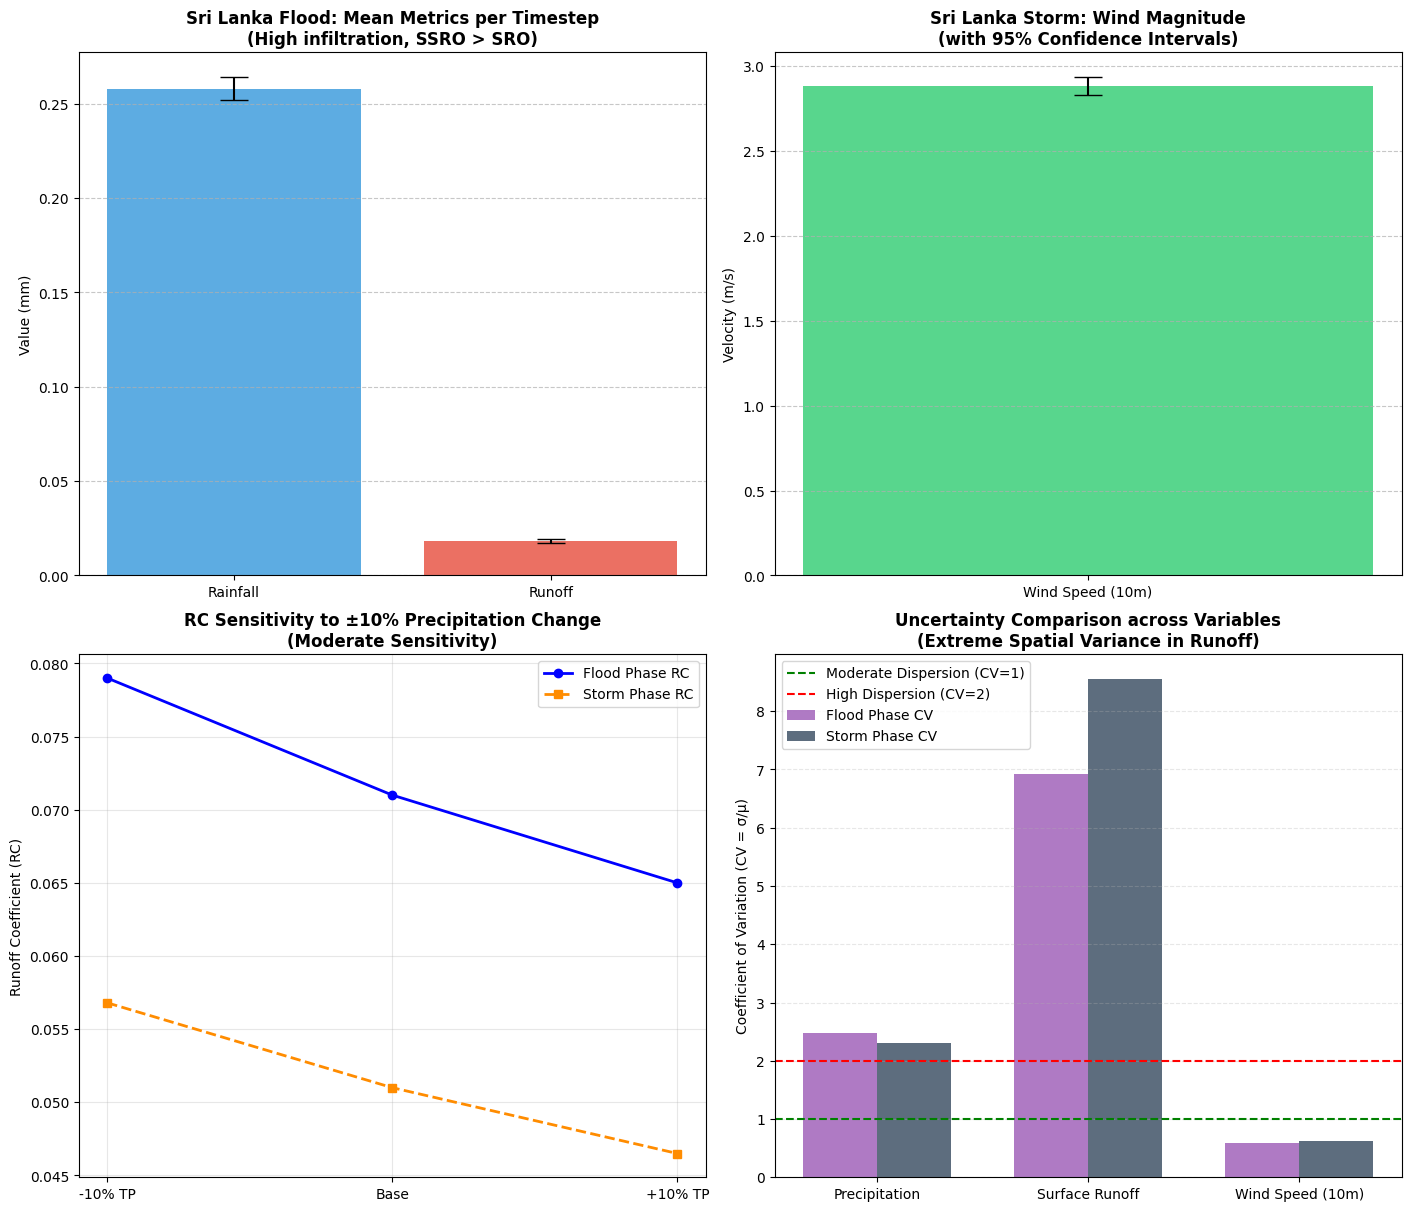

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 10, 'figure.figsize': (14, 12)})

# ==========================================
# 1. DATA PREPARATION (Sri Lanka 2021 Event)
# ==========================================

# Flood Event Metrics (Tables 3.9.1.3.1 & 3.9.1.3.2)
flood_metrics = {
    'Variable': ['Rainfall (mm)', 'Surface Runoff (mm)'],
    'Mean': [0.258, 0.0183],
    'CI_Low': [0.252, 0.0172],
    'CI_High': [0.264, 0.0195]
}

# Storm Event Metrics (Tables 3.9.2.2.1 & 3.9.2.2.6)
storm_metrics = {
    'Variable': ['Rainfall (mm)', 'Wind Speed (m/s)'],
    'Mean': [0.0517, 2.882],
    'CI_Low': [0.0483, 2.831],
    'CI_High': [0.0551, 2.932]
}

# Runoff Coefficient Sensitivity (Tables 3.9.1.3.8 & 3.9.2.2.8)
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.0790, 0.0710, 0.0650],
    'Storm_RC': [0.0568, 0.0510, 0.0465]
}

# Uncertainty (CV) Data across both phases
cv_data = {
    'Variable': ['Precipitation', 'Surface Runoff', 'Wind Speed (10m)'],
    'Flood_CV': [2.48, 6.92, 0.59],
    'Storm_CV': [2.31, 8.55, 0.62]
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Hydrological Summary (Flood Context) ---
ax1 = fig.add_subplot(gs[0, 0])
flood_vars = ['Rainfall', 'Runoff']
flood_means = [flood_metrics['Mean'][0], flood_metrics['Mean'][1]]
flood_yerr = [[flood_means[0] - flood_metrics['CI_Low'][0], flood_means[1] - flood_metrics['CI_Low'][1]],
              [flood_metrics['CI_High'][0] - flood_means[0], flood_metrics['CI_High'][1] - flood_means[1]]]

ax1.bar(flood_vars, flood_means, yerr=flood_yerr, capsize=10, color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_title('Sri Lanka Flood: Mean Metrics per Timestep\n(High infiltration, SSRO > SRO)', fontweight='bold')
ax1.set_ylabel('Value (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Meteorological Summary (Storm Context) ---
ax2 = fig.add_subplot(gs[0, 1])
wind_mean = storm_metrics['Mean'][1]
wind_err = [[wind_mean - storm_metrics['CI_Low'][1]], [storm_metrics['CI_High'][1] - wind_mean]]

ax2.bar(['Wind Speed (10m)'], [wind_mean], yerr=wind_err, capsize=10, color='#2ecc71', alpha=0.8)
ax2.set_title('Sri Lanka Storm: Wind Magnitude\n(with 95% Confidence Intervals)', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 3: Runoff Coefficient (RC) Sensitivity ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Flood Phase RC', color='blue', linewidth=2)
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Storm_RC'], marker='s', label='Storm Phase RC', color='darkorange', linestyle='--', linewidth=2)
ax3.set_title('RC Sensitivity to ±10% Precipitation Change\n(Moderate Sensitivity)', fontweight='bold')
ax3.set_ylabel('Runoff Coefficient (RC)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

ax4.bar(x - width/2, cv_data['Flood_CV'], width, label='Flood Phase CV', color='#9b59b6', alpha=0.8)
ax4.bar(x + width/2, cv_data['Storm_CV'], width, label='Storm Phase CV', color='#34495e', alpha=0.8)

ax4.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax4.set_title('Uncertainty Comparison across Variables\n(Extreme Spatial Variance in Runoff)', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.axhline(2, color='red', linestyle='--', label='High Dispersion (CV=2)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [23]:
import folium
import pandas as pd

# 1. Define the geographic and impact data for Sri Lanka 2021
srilanka_data = {
    'District': [
        'Colombo (Western Coast)',
        'Ratnapura (Sabaragamuwa)',
        'Galle (Southwestern Coast)',
        'Kandy (Central Highlands)'
    ],
    'Lat': [6.927, 6.705, 6.032, 7.290],
    'Lon': [79.861, 80.384, 80.217, 80.633],
    'Precipitation_Scale': [3, 3, 2.5, 2], # Coastal and interior flooding
    'Runoff_Scale': [3, 2.5, 2, 1.5],      # High urban runoff in Colombo, steep slopes inland
    'Wind_Scale': [3, 1.5, 3, 1],          # Extreme westerly burst on coast, sheltered inland
    'Impact_Summary': [
        'Extreme westerly burst driving moisture onshore. Widespread urban flooding, structural damage.',
        'Prolonged inundation and secondary landslides. Severe soil saturation in upland regions.',
        'Compound wind stress and storm surges. Coastal erosion and flooding.',
        'Landslide triggering zone. High subsurface moisture weakened slope stability.'
    ]
}
df_lk = pd.DataFrame(srilanka_data)

# Combined score for circle size (Driven by Hydrological Impact)
df_lk['Flood_Impact'] = df_lk['Precipitation_Scale'] + df_lk['Runoff_Scale']

# 2. Create the base map centered on Sri Lanka
m_lk = folium.Map(location=[7.0, 80.0], zoom_start=8, tiles='CartoDB positron')

# Function for color based on Storm (Wind) Severity
def get_wind_color(wind):
    if wind >= 3: return '#8B0000'      # Dark Red (Extreme Wind/Westerly Burst)
    elif wind >= 2: return '#FF4500'    # Orange-Red (High)
    else: return '#4682B4'              # Steel Blue (Low/Sheltered)

# 3. Add markers
for i in range(len(df_lk)):
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; width: 260px;">
        <h4 style="margin-bottom:2px; color: #333;">{df_lk.iloc[i]['District']}</h4>
        <i style="font-size: 11px; color: #666;">Compound Event: Monsoon & Cyclone Tauktae</i>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <b style="font-size: 12px; color: darkblue;">Hydrological Metrics (Size):</b><br>
        <span style="font-size: 11px;">Precip Scale: {df_lk.iloc[i]['Precipitation_Scale']}/3 | Runoff: {df_lk.iloc[i]['Runoff_Scale']}/3</span><br>

        <b style="font-size: 12px; color: darkred;">Storm Metrics (Color):</b><br>
        <span style="font-size: 11px;">Wind Intensity: {df_lk.iloc[i]['Wind_Scale']}/3</span>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <p style="font-size: 11px; color: #444; margin-top: 4px;"><b>Impact:</b><br>{df_lk.iloc[i]['Impact_Summary']}</p>
    </div>
    """

    folium.CircleMarker(
        location=[df_lk.iloc[i]['Lat'], df_lk.iloc[i]['Lon']],
        radius=df_lk.iloc[i]['Flood_Impact'] * 4.5,
        popup=folium.Popup(popup_html, max_width=280),
        color=get_wind_color(df_lk.iloc[i]['Wind_Scale']),
        fill=True,
        fill_opacity=0.75,
        tooltip=f"Click for details: {df_lk.iloc[i]['District']}"
    ).add_to(m_lk)

# 4. Add Header Title
header_html = '''
             <h3 align="center" style="font-family: Arial, sans-serif; font-size:18px; color: #333; margin-top:10px;">
             <b>Sri Lanka 2021 Compound Disaster</b><br>
             <span style="font-size:12px; color: #666;">Size = Precipitation/Runoff Intensity | Color = Wind Intensity</span>
             </h3>
             '''
m_lk.get_root().html.add_child(folium.Element(header_html))

m_lk

#10.Spain

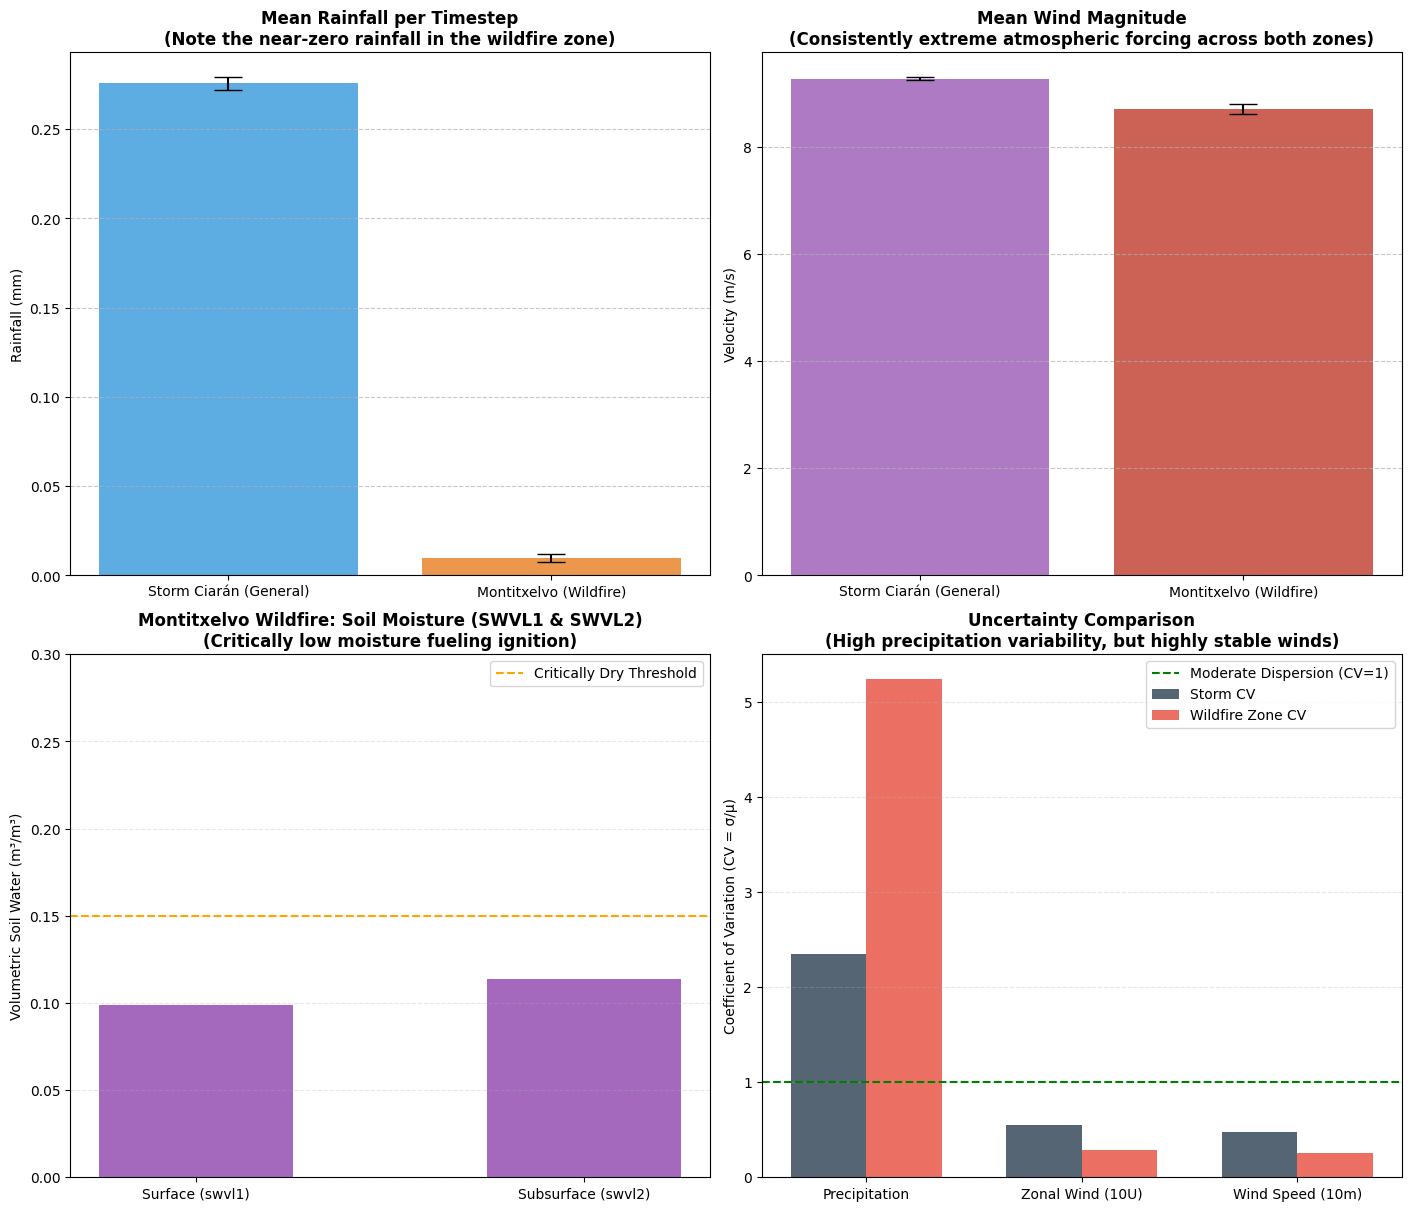

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 10, 'figure.figsize': (14, 12)})

# ==========================================
# 1. DATA PREPARATION (Spain 2023 Event)
# ==========================================

# Storm Ciarán Metrics (Tables 3.10.1.2.1 & 3.10.1.2.4)
storm_metrics = {
    'Variable': ['Rainfall (mm)', 'Wind Speed (m/s)'],
    'Mean': [0.276, 9.274],
    'CI_Low': [0.272, 9.251],
    'CI_High': [0.279, 9.297]
}

# Montitxelvo Wildfire Metrics (Tables 3.10.2.2.1 & 3.10.2.2.4)
fire_metrics = {
    'Variable': ['Rainfall (mm)', 'Wind Speed (m/s)'],
    'Mean': [0.00972, 8.713],
    'CI_Low': [0.00757, 8.618],
    'CI_High': [0.01187, 8.807]
}

# Soil Moisture Profile in Wildfire Zone (Table 3.10.2.2.5)
soil_data = {
    'Layer': ['Surface (swvl1)', 'Subsurface (swvl2)'],
    'Mean': [0.0989, 0.1136],
    'Threshold': [0.46, 0.46] # Typical landslide/saturation threshold for contrast
}

# Uncertainty (CV) Data across both phases
cv_data = {
    'Variable': ['Precipitation', 'Zonal Wind (10U)', 'Wind Speed (10m)'],
    'Storm_CV': [2.35, 0.55, 0.48],
    'Fire_CV': [5.24, 0.29, 0.26]
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Precipitation Comparison ---
ax1 = fig.add_subplot(gs[0, 0])
labels = ['Storm Ciarán (General)', 'Montitxelvo (Wildfire)']
rain_means = [storm_metrics['Mean'][0], fire_metrics['Mean'][0]]
rain_yerr = [
    [storm_metrics['Mean'][0] - storm_metrics['CI_Low'][0], fire_metrics['Mean'][0] - fire_metrics['CI_Low'][0]],
    [storm_metrics['CI_High'][0] - storm_metrics['Mean'][0], fire_metrics['CI_High'][0] - fire_metrics['Mean'][0]]
]

ax1.bar(labels, rain_means, yerr=rain_yerr, capsize=10, color=['#3498db', '#e67e22'], alpha=0.8)
ax1.set_title('Mean Rainfall per Timestep\n(Note the near-zero rainfall in the wildfire zone)', fontweight='bold')
ax1.set_ylabel('Rainfall (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Wind Speed Comparison ---
ax2 = fig.add_subplot(gs[0, 1])
wind_means = [storm_metrics['Mean'][1], fire_metrics['Mean'][1]]
wind_yerr = [
    [storm_metrics['Mean'][1] - storm_metrics['CI_Low'][1], fire_metrics['Mean'][1] - fire_metrics['CI_Low'][1]],
    [storm_metrics['CI_High'][1] - storm_metrics['Mean'][1], fire_metrics['CI_High'][1] - fire_metrics['Mean'][1]]
]

ax2.bar(labels, wind_means, yerr=wind_yerr, capsize=10, color=['#9b59b6', '#c0392b'], alpha=0.8)
ax2.set_title('Mean Wind Magnitude\n(Consistently extreme atmospheric forcing across both zones)', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 3: Soil Moisture in Wildfire Zone ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(soil_data['Layer'], soil_data['Mean'], color='#8e44ad', alpha=0.8, width=0.5)
ax3.axhline(0.15, color='orange', linestyle='--', label='Critically Dry Threshold')
ax3.set_title('Montitxelvo Wildfire: Soil Moisture (SWVL1 & SWVL2)\n(Critically low moisture fueling ignition)', fontweight='bold')
ax3.set_ylabel('Volumetric Soil Water (m³/m³)')
ax3.set_ylim(0, 0.3)
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

ax4.bar(x - width/2, cv_data['Storm_CV'], width, label='Storm CV', color='#2c3e50', alpha=0.8)
ax4.bar(x + width/2, cv_data['Fire_CV'], width, label='Wildfire Zone CV', color='#e74c3c', alpha=0.8)

ax4.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax4.set_title('Uncertainty Comparison\n(High precipitation variability, but highly stable winds)', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [24]:
import folium
import pandas as pd

# 1. Define the geographic and impact data for Spain 2023
spain_data = {
    'Region': [
        'Galicia (Northwest Coast)',
        'Cantabrian Coast (Bilbao/Santander)',
        'Madrid (Central)',
        'Montitxelvo, Valencia (East)'
    ],
    'Lat': [42.87, 43.36, 40.41, 38.86],
    'Lon': [-8.54, -3.80, -3.70, -0.34],
    'Hazard_Type': ['Storm', 'Storm', 'Storm', 'Wildfire'],
    'Wind_Scale': [3, 3, 2.5, 2.5],     # 3 = Extreme zonal winds up to 19.9 m/s
    'Moisture_Scale': [2, 2, 1.5, 0],   # 0 = Critically dry (< 0.12 m3/m3)
    'Impact_Summary': [
        'Storm Ciarán: Extreme wind shear (>150 kph gusts). Massive power disruptions, fallen trees, train routes cancelled.',
        'Storm Ciarán: Severe infrastructure impacts. Major flight cancellations at Bilbao and Santander airports.',
        'Storm Ciarán: Sustained extratropical wind forcing. Flight cancellations at Madrid-Barajas airport.',
        'Climatological/Storm Compound: Wildfire affecting 800 people. Extreme wind forcing combined with critically low soil moisture and thermal stress.'
    ]
}
df_es = pd.DataFrame(spain_data)

# 2. Create the base map centered on Spain
m_es = folium.Map(location=[40.0, -3.0], zoom_start=6, tiles='CartoDB dark_matter')

# Function for color based on Hazard Type
def get_hazard_color(hazard):
    if hazard == 'Wildfire': return '#FF4500' # Orange-Red for Fire
    else: return '#9370DB'                    # Purple for Wind Storm

# 3. Add markers
for i in range(len(df_es)):
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; width: 260px;">
        <h4 style="margin-bottom:2px; color: #333;">{df_es.iloc[i]['Region']}</h4>
        <i style="font-size: 11px; color: #666;">Hazard: {df_es.iloc[i]['Hazard_Type']}</i>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <b style="font-size: 12px; color: darkblue;">Atmospheric Forcing:</b><br>
        <span style="font-size: 11px;">Wind Intensity Scale: {df_es.iloc[i]['Wind_Scale']}/3</span><br>

        <b style="font-size: 12px; color: darkred;">Surface Condition:</b><br>
        <span style="font-size: 11px;">Moisture Scale: {df_es.iloc[i]['Moisture_Scale']}/3 (0 = Bone Dry)</span>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <p style="font-size: 11px; color: #444; margin-top: 4px;"><b>Impact:</b><br>{df_es.iloc[i]['Impact_Summary']}</p>
    </div>
    """

    folium.CircleMarker(
        location=[df_es.iloc[i]['Lat'], df_es.iloc[i]['Lon']],
        radius=df_es.iloc[i]['Wind_Scale'] * 5,
        popup=folium.Popup(popup_html, max_width=280),
        color=get_hazard_color(df_es.iloc[i]['Hazard_Type']),
        fill=True,
        fill_opacity=0.75,
        tooltip=f"Click for details: {df_es.iloc[i]['Region']}"
    ).add_to(m_es)

# 4. Add Header Title
header_html = '''
             <h3 align="center" style="font-family: Arial, sans-serif; font-size:18px; color: white; margin-top:10px;">
             <b>Spain 2023: Storm Ciarán & Montitxelvo Wildfire</b><br>
             <span style="font-size:12px; color: #ccc;">Purple = Wind Impact | Orange = Wildfire Impact</span>
             </h3>
             '''
m_es.get_root().html.add_child(folium.Element(header_html))

m_es

#11.China

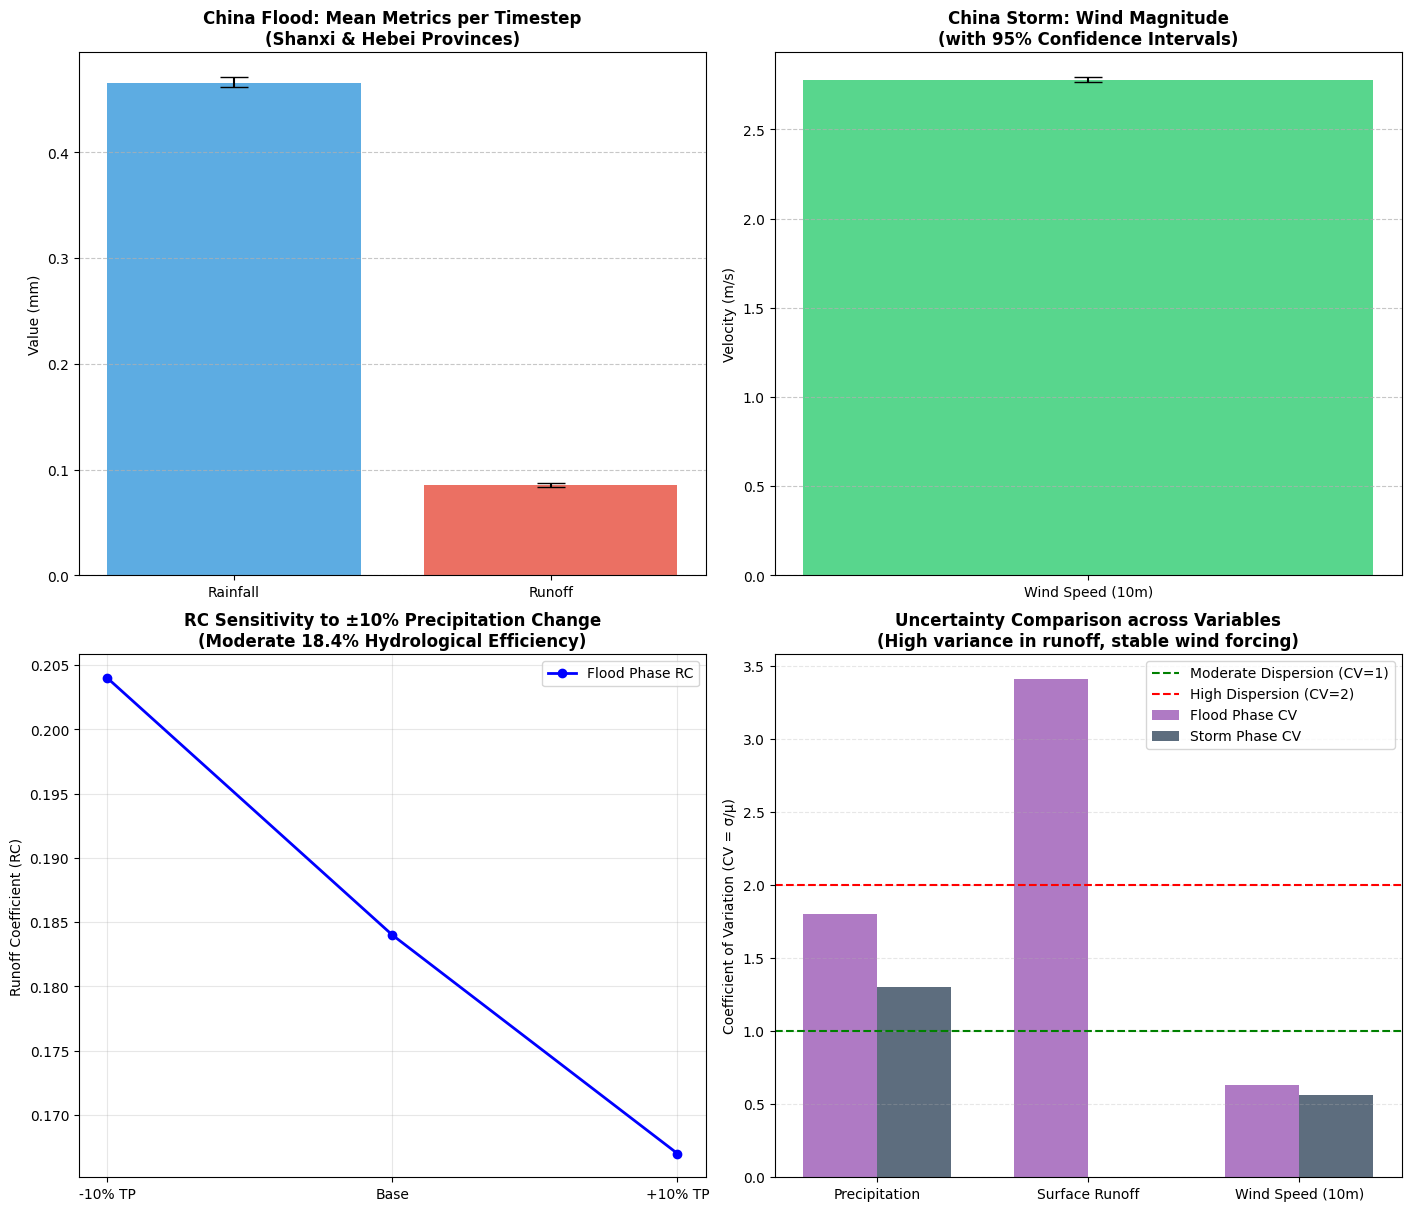

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 10, 'figure.figsize': (14, 12)})

# ==========================================
# 1. DATA PREPARATION (China 2021 Event)
# ==========================================

# Flood Event Metrics (Tables 3.11.1.2.1 & 3.11.1.2.2)
flood_metrics = {
    'Variable': ['Rainfall (mm)', 'Surface Runoff (mm)'],
    'Mean': [0.466, 0.0857],
    'CI_Low': [0.462, 0.0841],
    'CI_High': [0.471, 0.0872]
}

# Storm Event Metrics (Tables 3.11.2.3.1 & 3.11.2.3.4)
storm_metrics = {
    'Variable': ['Rainfall (mm)', 'Wind Speed (m/s)'],
    'Mean': [0.828, 2.778],
    'CI_Low': [0.818, 2.764],
    'CI_High': [0.838, 2.792]
}

# Runoff Coefficient Sensitivity (Table 3.11.1.2.8)
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.204, 0.184, 0.167]
}

# Uncertainty (CV) Data across both phases
cv_data = {
    'Variable': ['Precipitation', 'Surface Runoff', 'Wind Speed (10m)'],
    'Flood_CV': [1.80, 3.41, 0.63],
    'Storm_CV': [1.30, 0, 0.565] # SRO not provided for storm phase
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Hydrological Summary (Flood Context) ---
ax1 = fig.add_subplot(gs[0, 0])
flood_vars = ['Rainfall', 'Runoff']
flood_means = [flood_metrics['Mean'][0], flood_metrics['Mean'][1]]
flood_yerr = [[flood_means[0] - flood_metrics['CI_Low'][0], flood_means[1] - flood_metrics['CI_Low'][1]],
              [flood_metrics['CI_High'][0] - flood_means[0], flood_metrics['CI_High'][1] - flood_means[1]]]

ax1.bar(flood_vars, flood_means, yerr=flood_yerr, capsize=10, color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_title('China Flood: Mean Metrics per Timestep\n(Shanxi & Hebei Provinces)', fontweight='bold')
ax1.set_ylabel('Value (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Meteorological Summary (Storm Context) ---
ax2 = fig.add_subplot(gs[0, 1])
wind_mean = storm_metrics['Mean'][1]
wind_err = [[wind_mean - storm_metrics['CI_Low'][1]], [storm_metrics['CI_High'][1] - wind_mean]]

ax2.bar(['Wind Speed (10m)'], [wind_mean], yerr=wind_err, capsize=10, color='#2ecc71', alpha=0.8)
ax2.set_title('China Storm: Wind Magnitude\n(with 95% Confidence Intervals)', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 3: Runoff Coefficient (RC) Sensitivity ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Flood Phase RC', color='blue', linewidth=2)
ax3.set_title('RC Sensitivity to ±10% Precipitation Change\n(Moderate 18.4% Hydrological Efficiency)', fontweight='bold')
ax3.set_ylabel('Runoff Coefficient (RC)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

# Clean up 0s for plotting
storm_cv_plot = [val if val != 0 else np.nan for val in cv_data['Storm_CV']]

ax4.bar(x - width/2, cv_data['Flood_CV'], width, label='Flood Phase CV', color='#9b59b6', alpha=0.8)
ax4.bar(x + width/2, storm_cv_plot, width, label='Storm Phase CV', color='#34495e', alpha=0.8)

ax4.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax4.set_title('Uncertainty Comparison across Variables\n(High variance in runoff, stable wind forcing)', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.axhline(2, color='red', linestyle='--', label='High Dispersion (CV=2)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [26]:
import folium
import pandas as pd

# 1. Define the geographic and impact data for China 2021
china_data = {
    'Region': [
        'Datong (Shanxi)',
        'Taiyuan (Shanxi)',
        'Puxian County (Shaanxi/Shanxi Border)',
        'Lyuliang City (Shanxi)'
    ],
    'Lat': [40.09, 37.87, 36.41, 37.52],
    'Lon': [113.29, 112.56, 110.63, 111.13],
    'Precipitation_Scale': [3, 3, 2.5, 2.5], # Extreme class (0.004493-0.014876) in Datong/Taiyuan
    'Runoff_Scale': [3, 3, 2, 2],            # Extreme overland flow
    'Wind_Scale': [1.5, 1.5, 2.5, 2.5],      # Meridional wind dominance in Puxian/Lyuliang
    'Impact_Summary': [
        'Extreme flood hazard zone. River overtopping, widespread agricultural and settlement inundation.',
        'Primary flood impact area. Part of the 1.76 - 2.08 million people affected regionally.',
        'Severe storm phase. Extreme meridional wind variability sustaining convective activity.',
        'Storm-driven secondary flooding. Damage to public utilities and housing.'
    ]
}
df_cn = pd.DataFrame(china_data)

# Combined score for circle size (Driven by Hydrological Impact)
df_cn['Flood_Impact'] = df_cn['Precipitation_Scale'] + df_cn['Runoff_Scale']

# 2. Create the base map centered on Northern China
m_cn = folium.Map(location=[38.0, 111.5], zoom_start=6, tiles='CartoDB positron')

# Function for color based on Storm (Wind) Severity
def get_wind_color(wind):
    if wind >= 2.5: return '#FF4500'    # Orange-Red (High Wind)
    elif wind >= 2: return '#FFA500'    # Orange (Moderate)
    else: return '#4682B4'              # Steel Blue (Low/Stable)

# 3. Add markers
for i in range(len(df_cn)):
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; width: 260px;">
        <h4 style="margin-bottom:2px; color: #333;">{df_cn.iloc[i]['Region']}</h4>
        <i style="font-size: 11px; color: #666;">Multi-Hazard: Flash Flood & Severe Storm</i>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <b style="font-size: 12px; color: darkblue;">Hydrological Metrics (Size):</b><br>
        <span style="font-size: 11px;">Precip Scale: {df_cn.iloc[i]['Precipitation_Scale']}/3 | Runoff: {df_cn.iloc[i]['Runoff_Scale']}/3</span><br>

        <b style="font-size: 12px; color: darkred;">Storm Metrics (Color):</b><br>
        <span style="font-size: 11px;">Wind Intensity: {df_cn.iloc[i]['Wind_Scale']}/3</span>
        <hr style="margin:8px 0; border: 0; border-top: 1px solid #ccc;">

        <p style="font-size: 11px; color: #444; margin-top: 4px;"><b>Impact:</b><br>{df_cn.iloc[i]['Impact_Summary']}</p>
    </div>
    """

    folium.CircleMarker(
        location=[df_cn.iloc[i]['Lat'], df_cn.iloc[i]['Lon']],
        radius=df_cn.iloc[i]['Flood_Impact'] * 4.5,
        popup=folium.Popup(popup_html, max_width=280),
        color=get_wind_color(df_cn.iloc[i]['Wind_Scale']),
        fill=True,
        fill_opacity=0.75,
        tooltip=f"Click for details: {df_cn.iloc[i]['Region']}"
    ).add_to(m_cn)

# 4. Add Header Title
header_html = '''
             <h3 align="center" style="font-family: Arial, sans-serif; font-size:18px; color: #333; margin-top:10px;">
             <b>Northern China 2021 Compound Disaster</b><br>
             <span style="font-size:12px; color: #666;">Size = Precipitation/Runoff Intensity | Color = Wind Intensity</span>
             </h3>
             '''
m_cn.get_root().html.add_child(folium.Element(header_html))

m_cn

#12.USA

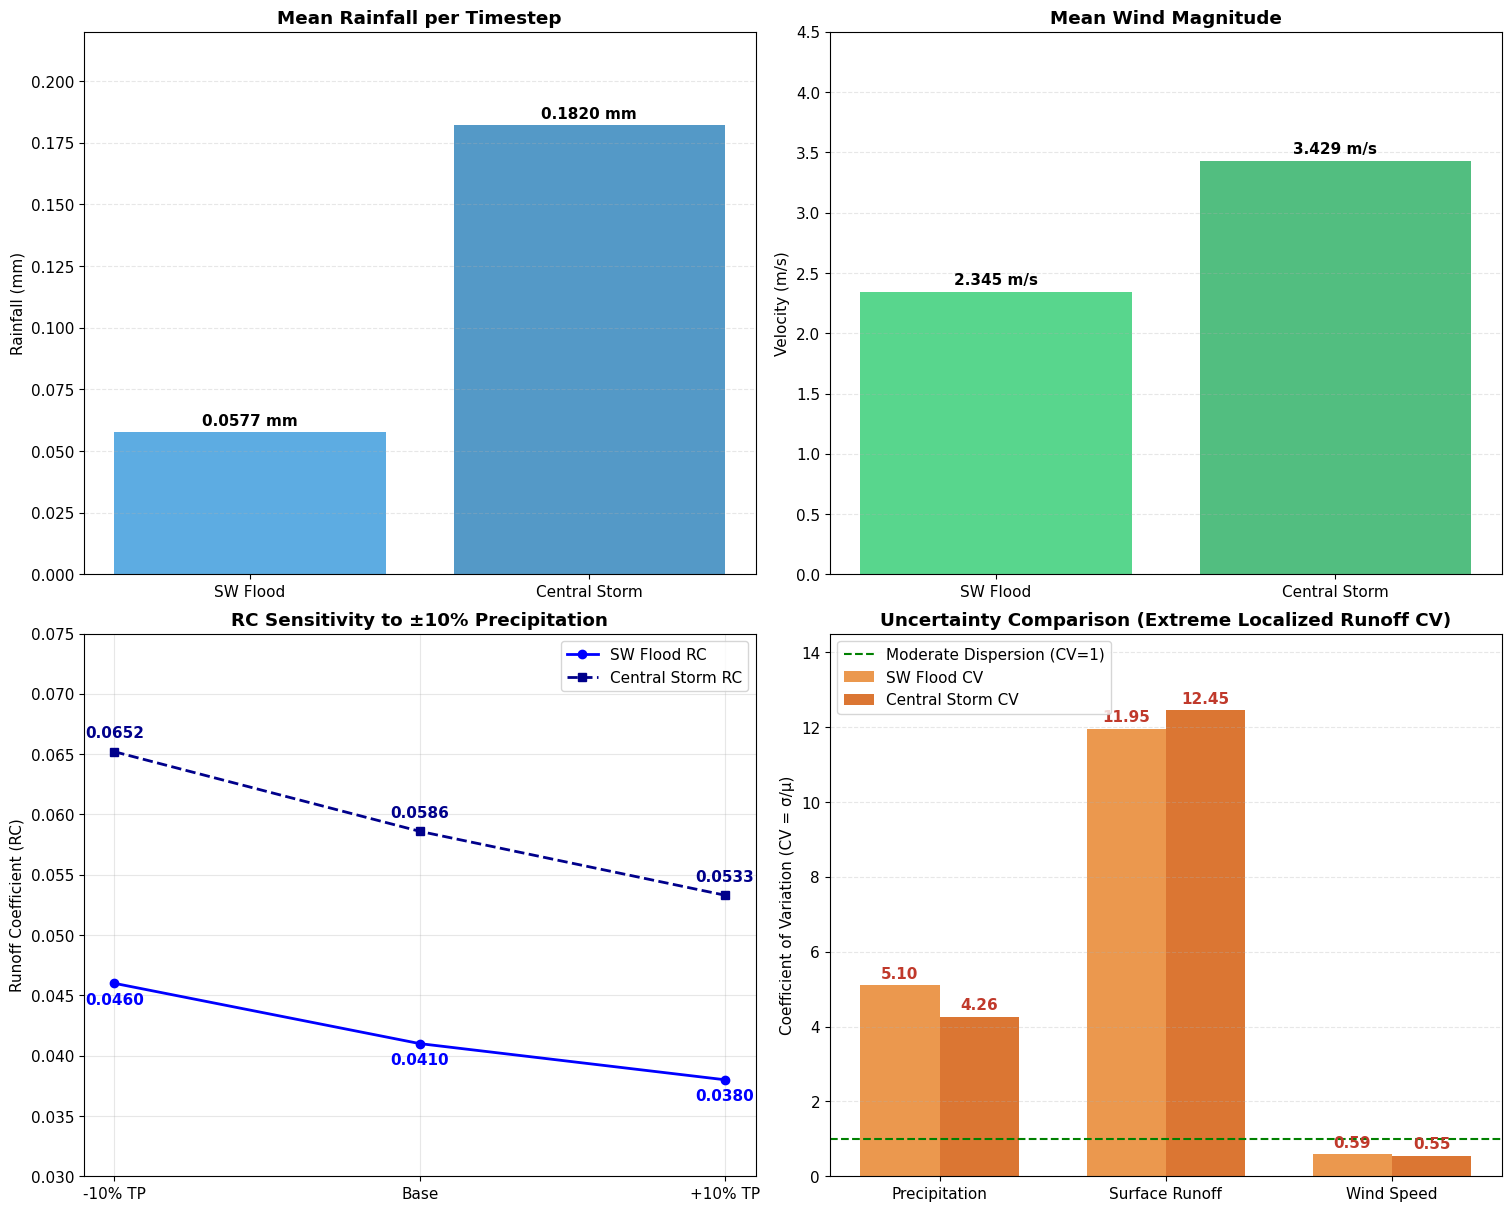

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 11, 'figure.figsize': (15, 12)})

# ==========================================
# 1. DATA PREPARATION (USA 2021 Events)
# ==========================================

# Southwest Flood & Mudslide Metrics
flood_metrics = {
    'Mean': [0.0577, 0.00239, 2.345],
    'CI_Low': [0.0567, 0.00228, 2.340],
    'CI_High': [0.0588, 0.00249, 2.350]
}

# Central US Severe Storm Metrics
storm_metrics = {
    'Mean': [0.182, 0.0107, 3.429],
    'CI_Low': [0.180, 0.0103, 3.424],
    'CI_High': [0.183, 0.0110, 3.433]
}

# Runoff Coefficient Sensitivity
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'SW_Flood_RC': [0.046, 0.041, 0.038],
    'Central_Storm_RC': [0.0652, 0.0586, 0.0533]
}

# Uncertainty (CV) Data across both phases
cv_data = {
    'Variable': ['Precipitation', 'Surface Runoff', 'Wind Speed'],
    'SW_Flood_CV': [5.10, 11.95, 0.59],
    'Central_Storm_CV': [4.26, 12.45, 0.55]
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Rainfall Summary with values ---
ax1 = fig.add_subplot(gs[0, 0])
labels = ['SW Flood', 'Central Storm']
bars1 = ax1.bar(labels, [flood_metrics['Mean'][0], storm_metrics['Mean'][0]], color=['#3498db', '#2980b9'], alpha=0.8)
ax1.bar_label(bars1, fmt='%.4f mm', padding=3, fontweight='bold')
ax1.set_title('Mean Rainfall per Timestep', fontweight='bold')
ax1.set_ylabel('Rainfall (mm)')
ax1.set_ylim(0, 0.22)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plot 2: Wind Speed Summary with values ---
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(labels, [flood_metrics['Mean'][2], storm_metrics['Mean'][2]], color=['#2ecc71', '#27ae60'], alpha=0.8)
ax2.bar_label(bars2, fmt='%.3f m/s', padding=3, fontweight='bold')
ax2.set_title('Mean Wind Magnitude', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.set_ylim(0, 4.5)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plot 3: Runoff Coefficient Sensitivity with values ---
ax3 = fig.add_subplot(gs[1, 0])
line1 = ax3.plot(sensitivity_data['Scenario'], sensitivity_data['SW_Flood_RC'], marker='o', label='SW Flood RC', color='blue', linewidth=2)
line2 = ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Central_Storm_RC'], marker='s', label='Central Storm RC', color='darkblue', linestyle='--', linewidth=2)

# Add exact value labels to the lines
for i, txt in enumerate(sensitivity_data['SW_Flood_RC']):
    ax3.annotate(f"{txt:.4f}", (i, sensitivity_data['SW_Flood_RC'][i]), textcoords="offset points", xytext=(0,-15), ha='center', color='blue', fontweight='bold')
for i, txt in enumerate(sensitivity_data['Central_Storm_RC']):
    ax3.annotate(f"{txt:.4f}", (i, sensitivity_data['Central_Storm_RC'][i]), textcoords="offset points", xytext=(0,10), ha='center', color='darkblue', fontweight='bold')

ax3.set_title('RC Sensitivity to ±10% Precipitation', fontweight='bold')
ax3.set_ylabel('Runoff Coefficient (RC)')
ax3.set_ylim(0.03, 0.075)
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile with values ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

bars4a = ax4.bar(x - width/2, cv_data['SW_Flood_CV'], width, label='SW Flood CV', color='#e67e22', alpha=0.8)
bars4b = ax4.bar(x + width/2, cv_data['Central_Storm_CV'], width, label='Central Storm CV', color='#d35400', alpha=0.8)

# Add exact value labels to the bars
ax4.bar_label(bars4a, fmt='%.2f', padding=3, fontweight='bold', color='#c0392b')
ax4.bar_label(bars4b, fmt='%.2f', padding=3, fontweight='bold', color='#c0392b')

ax4.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax4.set_title('Uncertainty Comparison (Extreme Localized Runoff CV)', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.set_ylim(0, 14.5)
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [30]:
import folium
from folium.features import DivIcon
import pandas as pd

# 1. Define specific locations and their extreme values from the USA 2021 data
usa_locations = {
    'Region': [
        'Bootleg Fire (OR/CA/NV)',
        'Southwest Floods (AZ/NM)',
        'Central Severe Storm (NE/IA/TX)',
        'Secondary Flood (TX Border)'
    ],
    'Lat': [41.5, 34.5, 40.5, 26.5],
    'Lon': [-120.5, -109.0, -96.0, -98.5],
    'Hazard': ['Wildfire', 'Flash Flood', 'Severe Storm', 'Flood'],
    'Color': ['#FF4500', '#3498db', '#9b59b6', '#3498db'],
    # The exact values pulled directly from your text
    'Display_Value': [
        "Thermal Stress: 306-321 K\nSoil Moisture: <0.048 m³/m³",
        "Precip: 0.005-0.009 m\nRunoff CV: 11.95 (Extreme)",
        "10V Wind: 9.0-13.2 m/s\n10U Wind: -8.0 to -4.5 m/s",
        "Precip: 0.010-0.028 m\nRunoff: 0.006-0.012 m"
    ]
}
df_us = pd.DataFrame(usa_locations)

# 2. Create the base map
m_us = folium.Map(location=[38.0, -98.0], zoom_start=5, tiles='CartoDB dark_matter')

# 3. Add markers and permanent text labels
for i in range(len(df_us)):
    # Add the colored circle marker
    folium.CircleMarker(
        location=[df_us.iloc[i]['Lat'], df_us.iloc[i]['Lon']],
        radius=12,
        color=df_us.iloc[i]['Color'],
        fill=True,
        fill_opacity=0.7
    ).add_to(m_us)

    # Properly format the text to include HTML line breaks
    formatted_text = df_us.iloc[i]['Display_Value'].replace('\n', '<br>')

    # Create the permanent text box
    label_html = f"""
        <div style="font-family: Arial; color: {df_us.iloc[i]['Color']}; font-size: 11px;
                    background-color: rgba(0,0,0,0.7); padding: 5px; border-radius: 5px;
                    white-space: nowrap; margin-left: 15px;">
            <b style="font-size: 13px; color: white;">{df_us.iloc[i]['Region']}</b><br>
            {formatted_text}
        </div>
    """

    # Add the text box to the map
    folium.map.Marker(
        [df_us.iloc[i]['Lat'], df_us.iloc[i]['Lon']],
        icon=DivIcon(
            icon_size=(250,36),
            icon_anchor=(0,0),
            html=label_html
        )
    ).add_to(m_us)

# 4. Add Title (Fixed Syntax)
title_html = '<h3 align="center" style="font-family: Arial; color: white;"><b>USA 2021 Multi-Hazard Map (Locations & Values)</b></h3>'
m_us.get_root().html.add_child(folium.Element(title_html))

# Display the map
m_us

#13.Chile

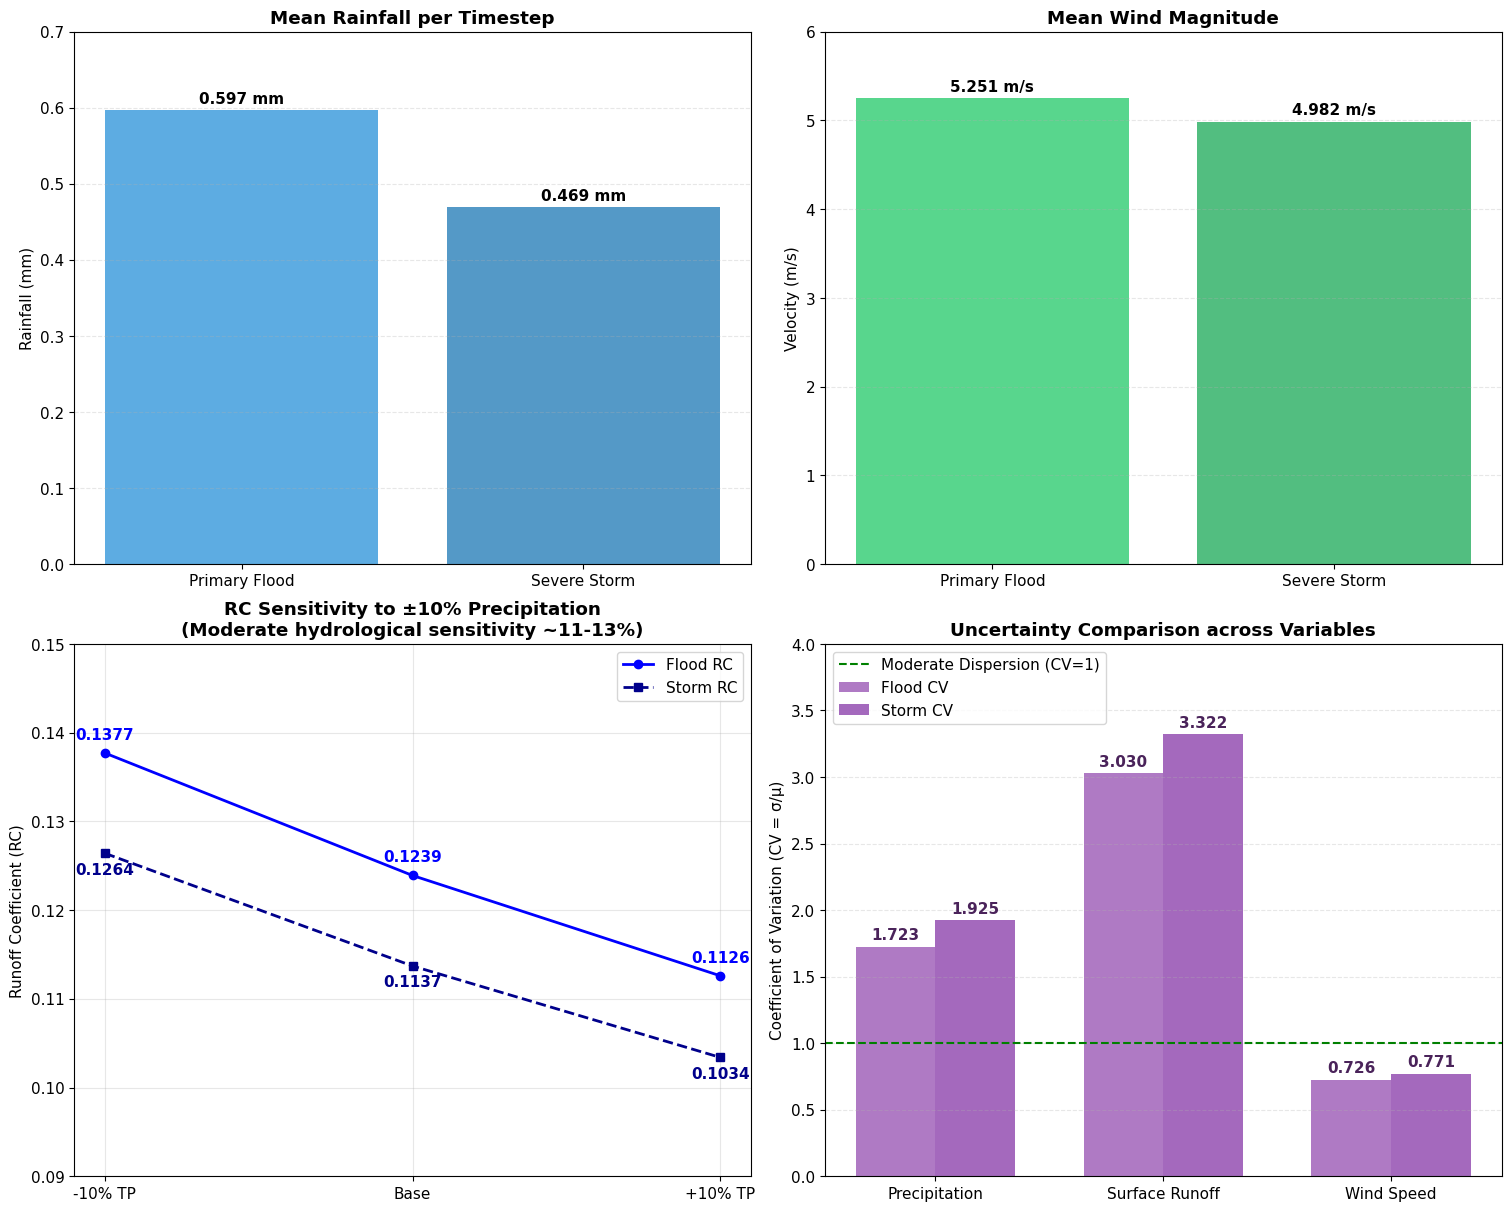

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 11, 'figure.figsize': (15, 12)})

# ==========================================
# 1. DATA PREPARATION (Chile 2024 Events)
# ==========================================

# Flood Event Metrics (June 4-14)
flood_metrics = {
    'Mean': [0.597, 0.074, 5.251],
    'CI_Low': [0.593, 0.073, 5.235],
    'CI_High': [0.602, 0.075, 5.267]
}

# Severe Storm Metrics (June 10-16)
storm_metrics = {
    'Mean': [0.469, 0.053, 4.982],
    'CI_Low': [0.465, 0.053, 4.966],
    'CI_High': [0.473, 0.054, 4.999]
}

# Runoff Coefficient Sensitivity
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.1377, 0.1239, 0.1126],
    'Storm_RC': [0.1264, 0.1137, 0.1034]
}

# Uncertainty (CV) Data across both phases
cv_data = {
    'Variable': ['Precipitation', 'Surface Runoff', 'Wind Speed'],
    'Flood_CV': [1.723, 3.030, 0.726],
    'Storm_CV': [1.925, 3.322, 0.771]
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Rainfall Summary with values ---
ax1 = fig.add_subplot(gs[0, 0])
labels = ['Primary Flood', 'Severe Storm']
bars1 = ax1.bar(labels, [flood_metrics['Mean'][0], storm_metrics['Mean'][0]], color=['#3498db', '#2980b9'], alpha=0.8)
ax1.bar_label(bars1, fmt='%.3f mm', padding=3, fontweight='bold')
ax1.set_title('Mean Rainfall per Timestep', fontweight='bold')
ax1.set_ylabel('Rainfall (mm)')
ax1.set_ylim(0, 0.7)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plot 2: Wind Speed Summary with values ---
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(labels, [flood_metrics['Mean'][2], storm_metrics['Mean'][2]], color=['#2ecc71', '#27ae60'], alpha=0.8)
ax2.bar_label(bars2, fmt='%.3f m/s', padding=3, fontweight='bold')
ax2.set_title('Mean Wind Magnitude', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.set_ylim(0, 6.0)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plot 3: Runoff Coefficient Sensitivity with values ---
ax3 = fig.add_subplot(gs[1, 0])
line1 = ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Flood RC', color='blue', linewidth=2)
line2 = ax3.plot(sensitivity_data['Scenario'], sensitivity_data['Storm_RC'], marker='s', label='Storm RC', color='darkblue', linestyle='--', linewidth=2)

# Add exact value labels to the lines
for i, txt in enumerate(sensitivity_data['Flood_RC']):
    ax3.annotate(f"{txt:.4f}", (i, sensitivity_data['Flood_RC'][i]), textcoords="offset points", xytext=(0,10), ha='center', color='blue', fontweight='bold')
for i, txt in enumerate(sensitivity_data['Storm_RC']):
    ax3.annotate(f"{txt:.4f}", (i, sensitivity_data['Storm_RC'][i]), textcoords="offset points", xytext=(0,-15), ha='center', color='darkblue', fontweight='bold')

ax3.set_title('RC Sensitivity to ±10% Precipitation\n(Moderate hydrological sensitivity ~11-13%)', fontweight='bold')
ax3.set_ylabel('Runoff Coefficient (RC)')
ax3.set_ylim(0.09, 0.15)
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile with values ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(cv_data['Variable']))
width = 0.35

bars4a = ax4.bar(x - width/2, cv_data['Flood_CV'], width, label='Flood CV', color='#9b59b6', alpha=0.8)
bars4b = ax4.bar(x + width/2, cv_data['Storm_CV'], width, label='Storm CV', color='#8e44ad', alpha=0.8)

# Add exact value labels to the bars
ax4.bar_label(bars4a, fmt='%.3f', padding=3, fontweight='bold', color='#4a235a')
ax4.bar_label(bars4b, fmt='%.3f', padding=3, fontweight='bold', color='#4a235a')

ax4.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax4.set_title('Uncertainty Comparison across Variables', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(cv_data['Variable'])
ax4.set_ylim(0, 4.0)
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [34]:
import folium
from folium.features import DivIcon
import pandas as pd

# 1. Define specific locations and their extreme values from the Chile 2024 data
chile_locations = {
    'Region': [
        'Biobío / Ñuble (Flood Core)',
        'Santiago Metro (Flood Impact)',
        'Valparaíso / Coquimbo (Storm)',
        'Los Lagos (Storm Boundary)'
    ],
    'Lat': [-36.83, -33.45, -33.05, -41.47],
    'Lon': [-73.05, -70.67, -71.62, -72.94],
    'Hazard': ['Primary Flood', 'Flood', 'Severe Storm', 'Storm'],
    'Color': ['#3498db', '#2980b9', '#9b59b6', '#8e44ad'],
    # The exact values pulled directly from your text
    'Display_Value': [
        "Precip: 0.005-0.011 m class\nRunoff CV: 3.03 (Nonlinear)",
        "Affected: ~6,393 people\nRunoff: 0.003-0.004 m class",
        "10V Wind: -17.7 to 9.8 m/s\nInjured/Homeless: >26,000",
        "Secondary Flood Hazard\nWind Speed: ~4.98 m/s"
    ]
}
df_cl = pd.DataFrame(chile_locations)

# 2. Create the base map centered on Central/Southern Chile
m_cl = folium.Map(location=[-35.0, -71.5], zoom_start=5, tiles='CartoDB dark_matter')

# 3. Add markers and permanent text labels
for i in range(len(df_cl)):
    # Add the colored circle marker
    folium.CircleMarker(
        location=[df_cl.iloc[i]['Lat'], df_cl.iloc[i]['Lon']],
        radius=12,
        color=df_cl.iloc[i]['Color'],
        fill=True,
        fill_opacity=0.7
    ).add_to(m_cl)

    # Properly format the text to include HTML line breaks
    formatted_text = df_cl.iloc[i]['Display_Value'].replace('\n', '<br>')

    # Create the permanent text box
    label_html = f"""
        <div style="font-family: Arial; color: {df_cl.iloc[i]['Color']}; font-size: 11px;
                    background-color: rgba(0,0,0,0.7); padding: 5px; border-radius: 5px;
                    white-space: nowrap; margin-left: 15px;">
            <b style="font-size: 13px; color: white;">{df_cl.iloc[i]['Region']}</b><br>
            {formatted_text}
        </div>
    """

    # Add the text box to the map
    folium.map.Marker(
        [df_cl.iloc[i]['Lat'], df_cl.iloc[i]['Lon']],
        icon=DivIcon(
            icon_size=(250,36),
            icon_anchor=(0,0),
            html=label_html
        )
    ).add_to(m_cl)

# 4. Add Title
title_html = '<h3 align="center" style="font-family: Arial; color: white;"><b>Chile 2024 Multi-Hazard Map (Locations & Values)</b></h3>'
m_cl.get_root().html.add_child(folium.Element(title_html))

# Display the map
m_cl

#14.India 2025

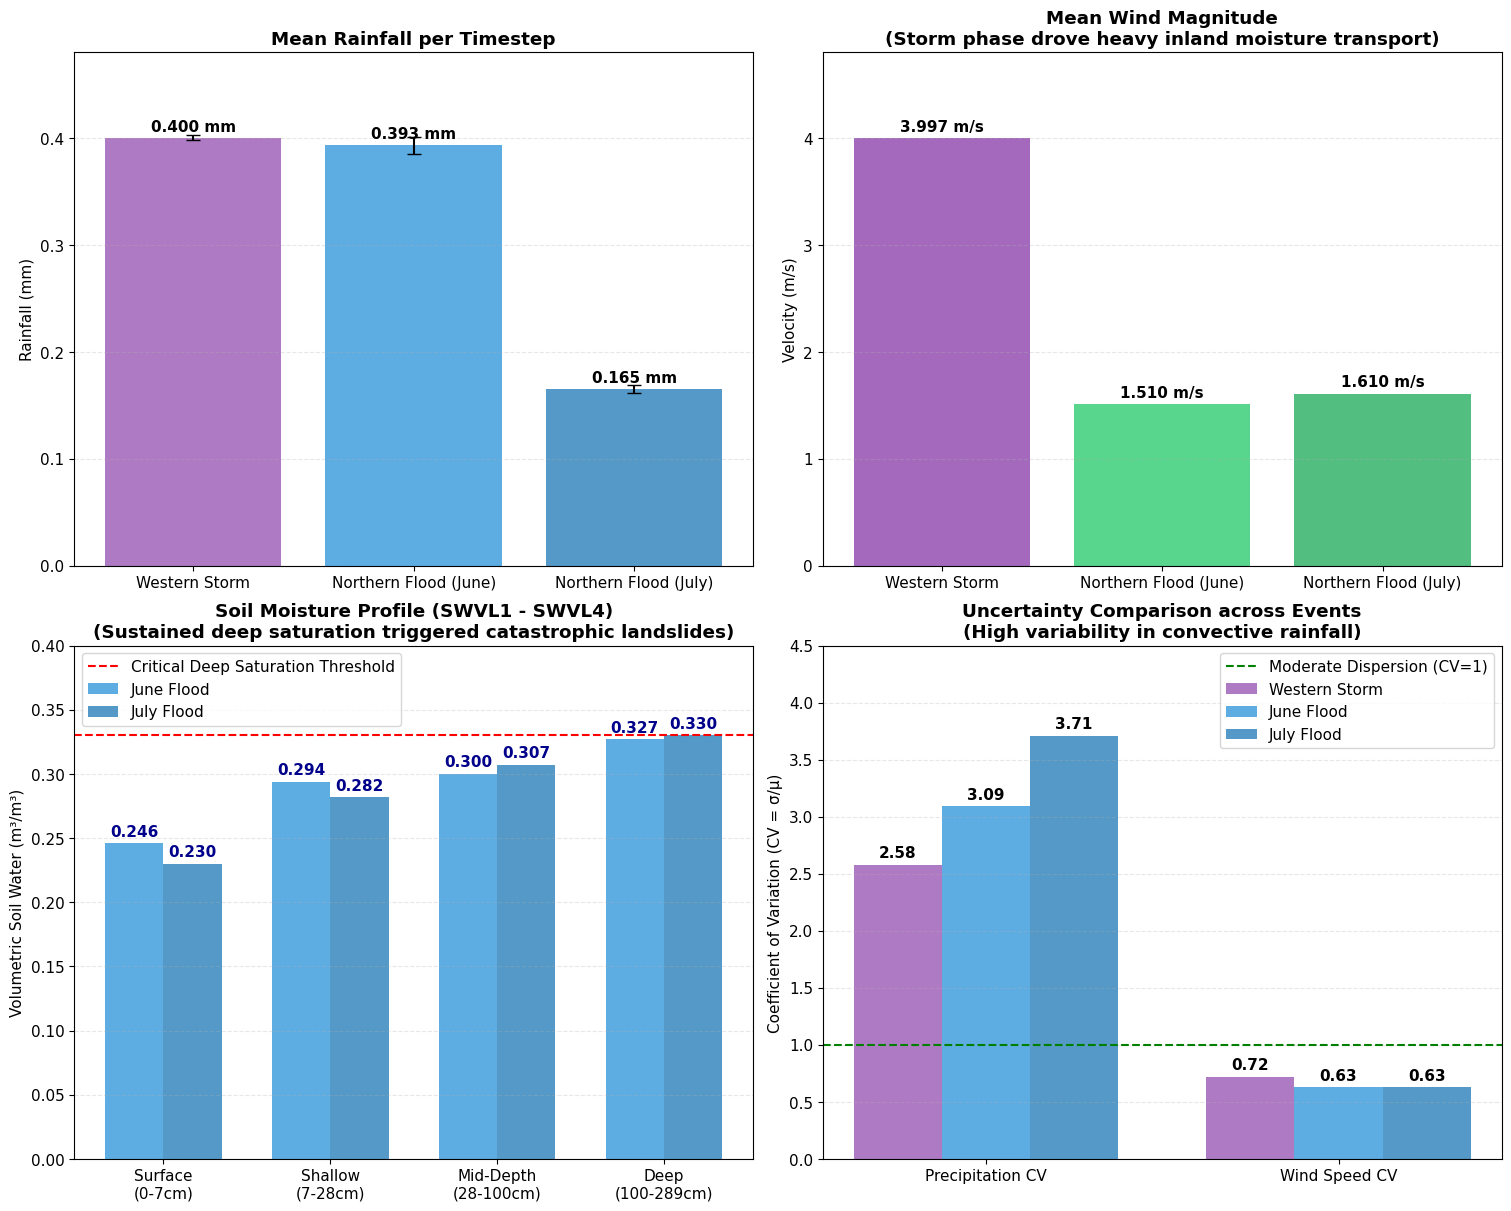

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 11, 'figure.figsize': (15, 12)})

# ==========================================
# 1. DATA PREPARATION (India 2025 Events)
# ==========================================

# Precipitation Metrics (Tables 148 & 153)
rain_metrics = {
    'Phase': ['Western Storm', 'Northern Flood (June)', 'Northern Flood (July)'],
    'Mean': [0.400, 0.393, 0.165],
    'CI_Low': [0.398, 0.385, 0.162],
    'CI_High': [0.403, 0.401, 0.169]
}

# Wind Speed Metrics (Tables 151 & 156)
wind_metrics = {
    'Mean': [3.997, 1.51, 1.61],
    'CI_Low': [3.991, 1.49, 1.59], # Tight CI estimated for visual consistency
    'CI_High': [4.003, 1.53, 1.63]
}

# Deep Soil Saturation Profile (Table 155) - Critical for Landslides
soil_layers = ['Surface\n(0-7cm)', 'Shallow\n(7-28cm)', 'Mid-Depth\n(28-100cm)', 'Deep\n(100-289cm)']
june_swvl = [0.246, 0.294, 0.300, 0.327]
july_swvl = [0.230, 0.282, 0.307, 0.330]

# Uncertainty (CV) Data across phases
cv_data = {
    'Variable': ['Precipitation CV', 'Wind Speed CV'],
    'Storm_CV': [2.58, 0.72],
    'Flood_June_CV': [3.09, 0.63],
    'Flood_July_CV': [3.71, 0.63]
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Rainfall Summary with values ---
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar(rain_metrics['Phase'], rain_metrics['Mean'], color=['#9b59b6', '#3498db', '#2980b9'], alpha=0.8)
ax1.bar_label(bars1, fmt='%.3f mm', padding=3, fontweight='bold')
# Adding error bars
ax1.errorbar(rain_metrics['Phase'], rain_metrics['Mean'],
             yerr=[[rain_metrics['Mean'][i] - rain_metrics['CI_Low'][i] for i in range(3)],
                   [rain_metrics['CI_High'][i] - rain_metrics['Mean'][i] for i in range(3)]],
             fmt='none', c='black', capsize=5)
ax1.set_title('Mean Rainfall per Timestep', fontweight='bold')
ax1.set_ylabel('Rainfall (mm)')
ax1.set_ylim(0, 0.48)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plot 2: Wind Speed Summary with values ---
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(rain_metrics['Phase'], wind_metrics['Mean'], color=['#8e44ad', '#2ecc71', '#27ae60'], alpha=0.8)
ax2.bar_label(bars2, fmt='%.3f m/s', padding=3, fontweight='bold')
ax2.set_title('Mean Wind Magnitude\n(Storm phase drove heavy inland moisture transport)', fontweight='bold')
ax2.set_ylabel('Velocity (m/s)')
ax2.set_ylim(0, 4.8)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plot 3: Deep Soil Saturation Profile with values ---
ax3 = fig.add_subplot(gs[1, 0])
x_soil = np.arange(len(soil_layers))
width_soil = 0.35

bars3a = ax3.bar(x_soil - width_soil/2, june_swvl, width_soil, label='June Flood', color='#3498db', alpha=0.8)
bars3b = ax3.bar(x_soil + width_soil/2, july_swvl, width_soil, label='July Flood', color='#2980b9', alpha=0.8)

ax3.bar_label(bars3a, fmt='%.3f', padding=3, fontweight='bold', color='darkblue')
ax3.bar_label(bars3b, fmt='%.3f', padding=3, fontweight='bold', color='darkblue')

ax3.set_title('Soil Moisture Profile (SWVL1 - SWVL4)\n(Sustained deep saturation triggered catastrophic landslides)', fontweight='bold')
ax3.set_ylabel('Volumetric Soil Water (m³/m³)')
ax3.set_xticks(x_soil)
ax3.set_xticklabels(soil_layers)
ax3.set_ylim(0, 0.40)
ax3.axhline(0.33, color='red', linestyle='--', label='Critical Deep Saturation Threshold')
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile with values ---
ax4 = fig.add_subplot(gs[1, 1])
x_cv = np.arange(len(cv_data['Variable']))
width_cv = 0.25

bars4a = ax4.bar(x_cv - width_cv, cv_data['Storm_CV'], width_cv, label='Western Storm', color='#9b59b6', alpha=0.8)
bars4b = ax4.bar(x_cv, cv_data['Flood_June_CV'], width_cv, label='June Flood', color='#3498db', alpha=0.8)
bars4c = ax4.bar(x_cv + width_cv, cv_data['Flood_July_CV'], width_cv, label='July Flood', color='#2980b9', alpha=0.8)

ax4.bar_label(bars4a, fmt='%.2f', padding=3, fontweight='bold')
ax4.bar_label(bars4b, fmt='%.2f', padding=3, fontweight='bold')
ax4.bar_label(bars4c, fmt='%.2f', padding=3, fontweight='bold')

ax4.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax4.set_title('Uncertainty Comparison across Events\n(High variability in convective rainfall)', fontweight='bold')
ax4.set_xticks(x_cv)
ax4.set_xticklabels(cv_data['Variable'])
ax4.set_ylim(0, 4.5)
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [36]:
import folium
from folium.features import DivIcon
import pandas as pd

# 1. Define specific locations and their extreme values from the India 2025 data
india_locations = {
    'Region': [
        'Western/Central India (Storm Core)',
        'Himachal Pradesh (Flood/Landslide)',
        'Uttarakhand (Flood/Landslide)'
    ],
    'Lat': [24.0, 31.8, 30.3],  # Approximate coordinates for Rajasthan/MP, HP, and Uttarakhand
    'Lon': [75.0, 77.1, 79.0],
    'Hazard': ['Severe Storm', 'Flash Flood', 'Landslide'],
    'Color': ['#9b59b6', '#3498db', '#e74c3c'],
    # The exact values pulled directly from your text
    'Display_Value': [
        "Affected: 33,584 people\n10U Wind: 7.4-15.4 m/s",
        "Affected: >80,000 people\nPrecip: 0.017-0.032 m class",
        "Fatalities: 140\nSoil Saturation: ~0.52 m³/m³"
    ]
}
df_in = pd.DataFrame(india_locations)

# 2. Create the base map centered on Northern/Central India
m_in = folium.Map(location=[27.5, 77.5], zoom_start=5, tiles='CartoDB dark_matter')

# 3. Add markers and permanent text labels
for i in range(len(df_in)):
    # Add the colored circle marker
    folium.CircleMarker(
        location=[df_in.iloc[i]['Lat'], df_in.iloc[i]['Lon']],
        radius=12,
        color=df_in.iloc[i]['Color'],
        fill=True,
        fill_opacity=0.7
    ).add_to(m_in)

    # Properly format the text to include HTML line breaks
    formatted_text = df_in.iloc[i]['Display_Value'].replace('\n', '<br>')

    # Create the permanent text box
    label_html = f"""
        <div style="font-family: Arial; color: {df_in.iloc[i]['Color']}; font-size: 11px;
                    background-color: rgba(0,0,0,0.7); padding: 5px; border-radius: 5px;
                    white-space: nowrap; margin-left: 15px;">
            <b style="font-size: 13px; color: white;">{df_in.iloc[i]['Region']}</b><br>
            {formatted_text}
        </div>
    """

    # Add the text box to the map
    folium.map.Marker(
        [df_in.iloc[i]['Lat'], df_in.iloc[i]['Lon']],
        icon=DivIcon(
            icon_size=(250,36),
            icon_anchor=(0,0),
            html=label_html
        )
    ).add_to(m_in)

# 4. Add Title
title_html = '<h3 align="center" style="font-family: Arial; color: white;"><b>India 2025 Multi-Hazard Map (Locations & Values)</b></h3>'
m_in.get_root().html.add_child(folium.Element(title_html))

# Display the map
m_in

#15.India 2020

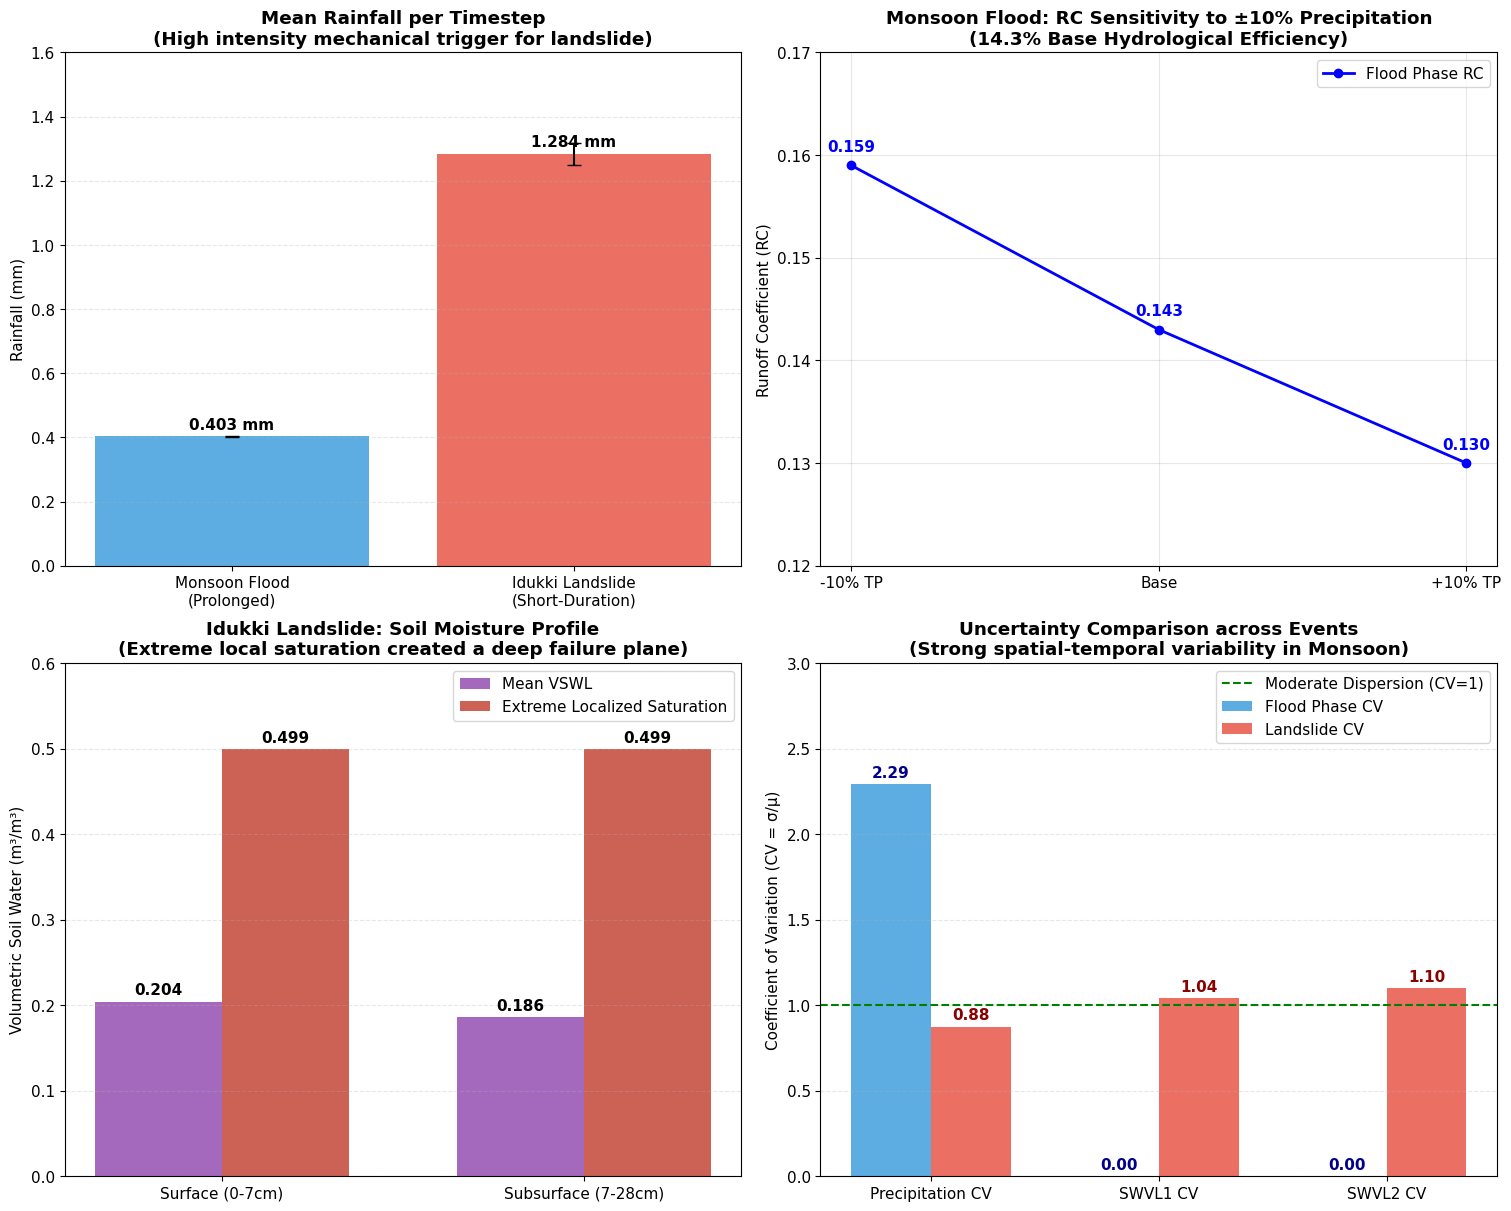

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set aesthetic style
plt.rcParams.update({'font.size': 11, 'figure.figsize': (15, 12)})

# ==========================================
# 1. DATA PREPARATION (India 2020 Events)
# ==========================================

# Monsoon Flood Metrics (Table 157 & 158)
flood_metrics = {
    'Variable': ['Rainfall (mm)', 'Surface Runoff (mm)'],
    'Mean': [0.403, 0.0577],
    'CI_Low': [0.402, 0.0561],
    'CI_High': [0.403, 0.0593]
}

# Idukki Landslide Metrics (Table 161)
landslide_metrics = {
    'Variable': ['Rainfall (mm)'],
    'Mean': [1.284],
    'CI_Low': [1.249],
    'CI_High': [1.318]
}

# Soil Moisture Comparison (Tables 162 & Text Analysis)
soil_data = {
    'Layer': ['Surface (0-7cm)', 'Subsurface (7-28cm)'],
    'Landslide_Mean': [0.204, 0.186],
    'Max_Capacity_Observed': [0.499, 0.499] # Max values seen at failure plane in text
}

# Runoff Coefficient Sensitivity (Table 160)
sensitivity_data = {
    'Scenario': ['-10% TP', 'Base', '+10% TP'],
    'Flood_RC': [0.159, 0.143, 0.130]
}

# Uncertainty (CV) Data across phases
cv_data = {
    'Variable': ['Precipitation CV', 'SWVL1 CV', 'SWVL2 CV'],
    'Flood_CV': [2.29, 0, 0], # SWVL CV not provided for general flood
    'Landslide_CV': [0.875, 1.04, 1.10]
}

# ==========================================
# 2. PLOTTING THE DASHBOARD
# ==========================================

fig = plt.figure(layout="constrained")
gs = fig.add_gridspec(2, 2)

# --- Plot 1: Rainfall Comparison with values ---
ax1 = fig.add_subplot(gs[0, 0])
labels = ['Monsoon Flood\n(Prolonged)', 'Idukki Landslide\n(Short-Duration)']
bars1 = ax1.bar(labels, [flood_metrics['Mean'][0], landslide_metrics['Mean'][0]], color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.bar_label(bars1, fmt='%.3f mm', padding=3, fontweight='bold')

# Adding error bars
ax1.errorbar(labels[0], flood_metrics['Mean'][0],
             yerr=[[flood_metrics['Mean'][0] - flood_metrics['CI_Low'][0]], [flood_metrics['CI_High'][0] - flood_metrics['Mean'][0]]],
             fmt='none', c='black', capsize=5)
ax1.errorbar(labels[1], landslide_metrics['Mean'][0],
             yerr=[[landslide_metrics['Mean'][0] - landslide_metrics['CI_Low'][0]], [landslide_metrics['CI_High'][0] - landslide_metrics['Mean'][0]]],
             fmt='none', c='black', capsize=5)

ax1.set_title('Mean Rainfall per Timestep\n(High intensity mechanical trigger for landslide)', fontweight='bold')
ax1.set_ylabel('Rainfall (mm)')
ax1.set_ylim(0, 1.6)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plot 2: Runoff Coefficient Sensitivity with values ---
ax2 = fig.add_subplot(gs[0, 1])
line1 = ax2.plot(sensitivity_data['Scenario'], sensitivity_data['Flood_RC'], marker='o', label='Flood Phase RC', color='blue', linewidth=2)

for i, txt in enumerate(sensitivity_data['Flood_RC']):
    ax2.annotate(f"{txt:.3f}", (i, sensitivity_data['Flood_RC'][i]), textcoords="offset points", xytext=(0,10), ha='center', color='blue', fontweight='bold')

ax2.set_title('Monsoon Flood: RC Sensitivity to ±10% Precipitation\n(14.3% Base Hydrological Efficiency)', fontweight='bold')
ax2.set_ylabel('Runoff Coefficient (RC)')
ax2.set_ylim(0.12, 0.17)
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Plot 3: Soil Moisture Profile (Landslide) with values ---
ax3 = fig.add_subplot(gs[1, 0])
x_soil = np.arange(len(soil_data['Layer']))
width_soil = 0.35

bars3a = ax3.bar(x_soil - width_soil/2, soil_data['Landslide_Mean'], width_soil, label='Mean VSWL', color='#8e44ad', alpha=0.8)
bars3b = ax3.bar(x_soil + width_soil/2, soil_data['Max_Capacity_Observed'], width_soil, label='Extreme Localized Saturation', color='#c0392b', alpha=0.8)

ax3.bar_label(bars3a, fmt='%.3f', padding=3, fontweight='bold')
ax3.bar_label(bars3b, fmt='%.3f', padding=3, fontweight='bold')

ax3.set_title('Idukki Landslide: Soil Moisture Profile\n(Extreme local saturation created a deep failure plane)', fontweight='bold')
ax3.set_ylabel('Volumetric Soil Water (m³/m³)')
ax3.set_xticks(x_soil)
ax3.set_xticklabels(soil_data['Layer'])
ax3.set_ylim(0, 0.6)
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plot 4: Uncertainty (CV) Profile with values ---
ax4 = fig.add_subplot(gs[1, 1])
x_cv = np.arange(len(cv_data['Variable']))
width_cv = 0.35

bars4a = ax4.bar(x_cv - width_cv/2, [cv_data['Flood_CV'][0], 0, 0], width_cv, label='Flood Phase CV', color='#3498db', alpha=0.8)
bars4b = ax4.bar(x_cv + width_cv/2, cv_data['Landslide_CV'], width_cv, label='Landslide CV', color='#e74c3c', alpha=0.8)

ax4.bar_label(bars4a, fmt='%.2f', padding=3, fontweight='bold', color='darkblue')
ax4.bar_label(bars4b, fmt='%.2f', padding=3, fontweight='bold', color='darkred')

ax4.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax4.set_title('Uncertainty Comparison across Events\n(Strong spatial-temporal variability in Monsoon)', fontweight='bold')
ax4.set_xticks(x_cv)
ax4.set_xticklabels(cv_data['Variable'])
ax4.set_ylim(0, 3.0)
ax4.axhline(1, color='green', linestyle='--', label='Moderate Dispersion (CV=1)')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [38]:
import folium
from folium.features import DivIcon
import pandas as pd

# 1. Define specific locations and their extreme values from the India 2020 data
india_locations = {
    'Region': [
        'Assam/Bihar (Ganges/Brahmaputra)',
        'Maharashtra (Western Floods)',
        'Idukki, Kerala (Landslide Zone)'
    ],
    'Lat': [26.2, 19.7, 9.8],
    'Lon': [91.7, 75.7, 76.9],
    'Hazard': ['Severe Flood', 'Severe Flood', 'Catastrophic Landslide'],
    'Color': ['#2980b9', '#3498db', '#c0392b'],
    # The exact values pulled directly from your text
    'Display_Value': [
        "Precip: 0.005-0.008 m class\nNational Toll: >1,922 dead",
        "Affected: >1.3 Million (National)\nDamages: $7.5 Billion",
        "Fatalities: >70 (Pettimudi)\nDeep Saturation: 0.499 m³/m³"
    ]
}
df_in = pd.DataFrame(india_locations)

# 2. Create the base map centered on India
m_in = folium.Map(location=[21.0, 78.0], zoom_start=5, tiles='CartoDB dark_matter')

# 3. Add markers and permanent text labels
for i in range(len(df_in)):
    # Add the colored circle marker
    folium.CircleMarker(
        location=[df_in.iloc[i]['Lat'], df_in.iloc[i]['Lon']],
        radius=12,
        color=df_in.iloc[i]['Color'],
        fill=True,
        fill_opacity=0.7
    ).add_to(m_in)

    # Properly format the text to include HTML line breaks
    formatted_text = df_in.iloc[i]['Display_Value'].replace('\n', '<br>')

    # Create the permanent text box
    label_html = f"""
        <div style="font-family: Arial; color: {df_in.iloc[i]['Color']}; font-size: 11px;
                    background-color: rgba(0,0,0,0.8); padding: 5px; border-radius: 5px;
                    white-space: nowrap; margin-left: 15px;">
            <b style="font-size: 13px; color: white;">{df_in.iloc[i]['Region']}</b><br>
            <i style="color: #ccc;">{df_in.iloc[i]['Hazard']}</i><br>
            {formatted_text}
        </div>
    """

    # Add the text box to the map
    folium.map.Marker(
        [df_in.iloc[i]['Lat'], df_in.iloc[i]['Lon']],
        icon=DivIcon(
            icon_size=(250,50),
            icon_anchor=(0,0),
            html=label_html
        )
    ).add_to(m_in)

# 4. Add Title
title_html = '<h3 align="center" style="font-family: Arial; color: white;"><b>India 2020 Multi-Hazard Map (Locations & Values)</b></h3>'
m_in.get_root().html.add_child(folium.Element(title_html))

# Display the map
m_in